In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

## USDC

In [ ]:
FILE        = "USDCReg.xlsx"
DAILY_SHEET = "USDCDaily"
BS_SHEET    = "Circle"

START_DATE = "2022-09-30"
HAC_LAGS   = 7

# Calm subsample (paper main)
CALM_START = "2023-07-01"
CALM_END   = "2025-12-31"

# Stress definitions
STRESS_EVENT_START = "2023-03-09"
STRESS_EVENT_END   = "2023-03-20"

USE_HIGH_VIX_STRESS = True
HIGH_VIX_Q          = 0.90
RUN_SVB_EVENT_APPENDIX = True

# Winsorization for y
WINSORIZE_Y = True
WINSOR_LO_Q = 0.001   # 0.1%
WINSOR_HI_Q = 0.999   # 99.9%

# --------------------------
# Coin / spec mode controls
# --------------------------
# "COMPOSITE": force safety = z(L)+z(K)
# "SEPARATE": force L and K separately (z-scored in-sample)
BALANCE_SHEET_MODE = "AUTO"   # {"AUTO","COMPOSITE","SEPARATE"}

COIN_LABEL = "USDC"           # e.g., "USDC" or "USDT" (used only for labels / AUTO heuristic)


daily = pd.read_excel(FILE, sheet_name=DAILY_SHEET)
bs    = pd.read_excel(FILE, sheet_name=BS_SHEET)

daily["date"] = pd.to_datetime(daily["date"], errors="coerce").dt.tz_localize(None).dt.normalize()
bs["Date"]    = pd.to_datetime(bs["Date"], errors="coerce").dt.tz_localize(None).dt.normalize()
bs = bs.rename(columns={"Date": "date"})

# We only keep columns used in paper regressions
keep_cols = ["date", "L", "K", "VIX"]
missing_bs = [c for c in keep_cols if c not in bs.columns]
if missing_bs:
    raise ValueError(f"Missing required balance sheet columns in {BS_SHEET}: {missing_bs}")

df = daily.merge(
    bs[keep_cols],
    on="date",
    how="left"
)

df["exchange"] = df["exchange"].astype(str).str.lower().str.strip()

df = df[df["date"] >= pd.Timestamp(START_DATE)].copy()
df = df.sort_values(["exchange", "date"]).replace([np.inf, -np.inf], np.nan)

# Dependent variable (peg deviation)
df["y_raw"] = pd.to_numeric(df["log_peg"], errors="coerce")

# Microstructure controls
df["hl"]  = pd.to_numeric(df["hl_spread"], errors="coerce")
df["vol"] = np.log1p(pd.to_numeric(df["volume"], errors="coerce"))  # log vol

# Balance sheet regressors
# L = liquidity share = (cash + deposits) / reserves
# K = equity share    = (reserves - tokens issued) / reserves
df["L"] = pd.to_numeric(df["L"], errors="coerce")
df["K"] = pd.to_numeric(df["K"], errors="coerce")

# Macro risk control
df["vix"] = pd.to_numeric(df["VIX"], errors="coerce")

# Microstructure lags (by exchange)
df["hl_lag1"]  = df.groupby("exchange")["hl"].shift(1)
df["vol_lag1"] = df.groupby("exchange")["vol"].shift(1)

# AR(1) lag
df["y_raw_lag1"] = df.groupby("exchange")["y_raw"].shift(1)

# A) Event window around SVB / USDC depeg (appendix robustness)
df["stress_event"] = (
    (df["date"] >= pd.Timestamp(STRESS_EVENT_START)) &
    (df["date"] <= pd.Timestamp(STRESS_EVENT_END))
).astype(int)

# B) High-VIX regime (paper main stress definition)
if USE_HIGH_VIX_STRESS:
    vix_cut = df["vix"].quantile(HIGH_VIX_Q)
    df["stress_vix"] = (df["vix"] >= vix_cut).astype(int)
else:
    vix_cut = np.nan
    df["stress_vix"] = 0

def winsorize_series(s, lo_q=WINSOR_LO_Q, hi_q=WINSOR_HI_Q):
    s = s.astype(float)
    lo = s.quantile(lo_q)
    hi = s.quantile(hi_q)
    return s.clip(lower=lo, upper=hi), lo, hi

df["y"] = df["y_raw"].copy()
df["y_lag1"] = df["y_raw_lag1"].copy()

if WINSORIZE_Y:
    y_w, lo, hi = winsorize_series(df["y"])
    df["y"] = y_w
    # Recompute AR(1) lag from winsorized y (consistency)
    df["y_lag1"] = df.groupby("exchange")["y"].shift(1)
    print(f"Winsorized y at [{WINSOR_LO_Q:.3%},{WINSOR_HI_Q:.3%}] quantiles: lo={lo:.6g}, hi={hi:.6g}")

print("\n==========================================================")
print("DIAGNOSTICS")
print("==========================================================")
print("Exchanges:", df["exchange"].dropna().unique())
if df["date"].notna().any():
    print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

core = ["y", "L", "K", "vix", "hl_lag1", "vol_lag1", "y_lag1", "stress_event", "stress_vix"]
present_core = [c for c in core if c in df.columns]
print("\nNon-missing share (core vars):")
print(df[present_core].notna().mean().sort_values(ascending=False))

lk_nonmiss = df[["L", "K"]].dropna()
if len(lk_nonmiss) > 1:
    print("\nCorr(L,K) on non-missing rows:", lk_nonmiss.corr().iloc[0, 1])
else:
    print("\nCorr(L,K): not enough non-missing rows.")

if USE_HIGH_VIX_STRESS and np.isfinite(vix_cut):
    print(f"High-VIX cutoff (q={HIGH_VIX_Q:.0%}): {vix_cut:.4f}")

def zscore_in_sample(d, col):
    x = d[col].astype(float)
    m = x.mean()
    sd = x.std(ddof=0)
    if (sd is None) or (not np.isfinite(sd)) or (sd <= 0):
        return pd.Series(np.nan, index=d.index)
    return (x - m) / sd

def infer_balance_sheet_mode(file_name, daily_sheet_name, bs_sheet_name, coin_label):
    """
    AUTO heuristic:
      - If any identifier contains 'usdt' or 'tether' -> SEPARATE
      - else -> COMPOSITE
    """
    text = " ".join([str(file_name), str(daily_sheet_name), str(bs_sheet_name), str(coin_label)]).lower()
    if ("usdt" in text) or ("tether" in text):
        return "SEPARATE"
    return "COMPOSITE"

def get_effective_bs_mode():
    mode = str(BALANCE_SHEET_MODE).upper().strip()
    if mode not in {"AUTO", "COMPOSITE", "SEPARATE"}:
        raise ValueError("BALANCE_SHEET_MODE must be one of {'AUTO','COMPOSITE','SEPARATE'}")
    if mode == "AUTO":
        return infer_balance_sheet_mode(FILE, DAILY_SHEET, BS_SHEET, COIN_LABEL)
    return mode

BS_MODE_EFF = get_effective_bs_mode()
print(f"\nBalance-sheet spec mode (effective): {BS_MODE_EFF}")

def build_regressors_in_sample(d, include_vix=True, separate_lk=False):
    """
    Builds in-sample z-scored balance-sheet regressors and returns X columns.
    - If separate_lk=False: creates `safety = zL + zK`
    - If separate_lk=True:  creates `zL`, `zK`
    Also includes vix, hl_lag1, vol_lag1.
    """
    d = d.copy()
    d["zL"] = zscore_in_sample(d, "L")
    d["zK"] = zscore_in_sample(d, "K")

    rhs_cols = []
    if separate_lk:
        rhs_cols += ["zL", "zK"]
    else:
        d["safety"] = d["zL"] + d["zK"]
        rhs_cols += ["safety"]

    if include_vix:
        rhs_cols += ["vix"]

    rhs_cols += ["hl_lag1", "vol_lag1"]
    return d, rhs_cols

def run_fe_main_paper(data, label, use_ar1=True, separate_lk=False):
    """
    Main paper spec:
      y ~ [safety OR zL+zK separately] + vix + micro + FE + AR(1)
    """
    required = ["y", "exchange", "date", "L", "K", "vix", "hl_lag1", "vol_lag1"]
    if use_ar1:
        required += ["y_lag1"]

    d = data.dropna(subset=required).copy()
    print("\n====================", label, "====================")
    if len(d) == 0:
        print("❌ 0 observations after dropna.")
        return None

    d, rhs = build_regressors_in_sample(d, include_vix=True, separate_lk=separate_lk)

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = d[rhs].astype(float)

    if use_ar1:
        X = pd.concat([d[["y_lag1"]].astype(float), X], axis=1)

    X = pd.concat([X, ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = d["y"].astype(float)

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    print("Obs:", len(d))
    print("Exchanges:", d["exchange"].unique())
    print("Date range:", d["date"].min().date(), "to", d["date"].max().date())
    print("Spec:", "SEPARATE zL,zK" if separate_lk else "COMPOSITE safety=zL+zK", "| VIX + AR(1)" if use_ar1 else "| VIX")
    print(res.summary())
    return res

def run_fe_stress_interaction_paper(data, stress_col, label, use_ar1=True, separate_lk=False):
    """
    Stress interaction paper spec (AR1 only recommended):
      Composite mode:
        y ~ safety + vix + stress + safety*stress + vix*stress + micro + FE + AR1
      Separate L/K mode:
        y ~ zL + zK + vix + stress + zL*stress + zK*stress + vix*stress + micro + FE + AR1
    """
    required = ["y", "exchange", "date", "L", "K", "vix", stress_col, "hl_lag1", "vol_lag1"]
    if use_ar1:
        required += ["y_lag1"]

    d = data.dropna(subset=required).copy()
    print("\n====================", label, "====================")
    if len(d) == 0:
        print("❌ 0 observations after dropna.")
        return None

    # In-sample z-scoring
    d["zL"] = zscore_in_sample(d, "L")
    d["zK"] = zscore_in_sample(d, "K")

    # Optional centering of VIX for interaction stability (recommended)
    d["vix_c"] = d["vix"] - d["vix"].mean()

    d["stress"] = d[stress_col].astype(int)

    if separate_lk:
        d["zL_x_stress"]  = d["zL"] * d["stress"]
        d["zK_x_stress"]  = d["zK"] * d["stress"]
        d["vixc_x_stress"] = d["vix_c"] * d["stress"]

        rhs = ["zL", "zK", "vix_c", "stress", "zL_x_stress", "zK_x_stress", "vixc_x_stress", "hl_lag1", "vol_lag1"]
    else:
        d["safety"] = d["zL"] + d["zK"]
        d["safety_x_stress"] = d["safety"] * d["stress"]
        d["vixc_x_stress"]   = d["vix_c"] * d["stress"]

        rhs = ["safety", "vix_c", "stress", "safety_x_stress", "vixc_x_stress", "hl_lag1", "vol_lag1"]

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = d[rhs].astype(float)

    if use_ar1:
        X = pd.concat([d[["y_lag1"]].astype(float), X], axis=1)

    X = pd.concat([X, ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = d["y"].astype(float)

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    print("Stress col:", stress_col)
    print("Obs:", len(d))
    print("Exchanges:", d["exchange"].unique())
    print("Date range:", d["date"].min().date(), "to", d["date"].max().date())
    print("Spec:", "SEPARATE zL,zK interactions" if separate_lk else "COMPOSITE safety interaction", "| centered VIX interactions", "| AR(1)" if use_ar1 else "")
    print(res.summary())
    return res

df_full = df.copy()
df_calm = df[
    (df["date"] >= pd.Timestamp(CALM_START)) &
    (df["date"] <= pd.Timestamp(CALM_END))
].copy()

print("\nSample sizes (raw, before regression dropna):")
print("FULL:", len(df_full))
print("CALM:", len(df_calm))

# PAPER RUNS ONLY
# USDC default -> composite safety
# USDT default -> separate zL, zK
SEPARATE_LK = (BS_MODE_EFF == "SEPARATE")

print("\n==========================================================")
print("RUNNING PAPER SPECS ONLY")
print("==========================================================")

# A) Main tables: FULL and CALM (VIX + AR1)
res_full_main = run_fe_main_paper(
    df_full,
    f"{COIN_LABEL} | FULL: VIX + AR(1)",
    use_ar1=True,
    separate_lk=SEPARATE_LK
)

res_calm_main = run_fe_main_paper(
    df_calm,
    f"{COIN_LABEL} | CALM: VIX + AR(1)",
    use_ar1=True,
    separate_lk=SEPARATE_LK
)

# B) Main stress table: High-VIX regime interaction + AR1
if USE_HIGH_VIX_STRESS:
    res_stress_vix = run_fe_stress_interaction_paper(
        df_full,
        "stress_vix",
        f"{COIN_LABEL} | FULL: HIGH-VIX INTERACTION + AR(1) (TOP DECILE)",
        use_ar1=True,
        separate_lk=SEPARATE_LK
    )
else:
    res_stress_vix = None
    print("\nHigh-VIX stress disabled (USE_HIGH_VIX_STRESS=False).")

# C) Optional appendix robustness: SVB event-window interaction + AR1
if RUN_SVB_EVENT_APPENDIX:
    res_stress_event = run_fe_stress_interaction_paper(
        df_full,
        "stress_event",
        f"{COIN_LABEL} | APPENDIX: SVB EVENT INTERACTION + AR(1)",
        use_ar1=True,
        separate_lk=SEPARATE_LK
    )
else:
    res_stress_event = None
    print("\nSVB event appendix regression skipped (RUN_SVB_EVENT_APPENDIX=False).")

def extract_key_stats(res, label):
    if res is None:
        return {"spec": label, "nobs": np.nan, "r2": np.nan}
    out = {"spec": label, "nobs": int(res.nobs), "r2": float(res.rsquared)}
    # pull common coefficients if present
    for k in ["y_lag1", "safety", "zL", "zK", "vix", "vix_c", "stress",
              "safety_x_stress", "zL_x_stress", "zK_x_stress", "vixc_x_stress",
              "hl_lag1", "vol_lag1"]:
        if k in res.params.index:
            out[f"{k}_coef"] = float(res.params[k])
            out[f"{k}_p"]    = float(res.pvalues[k])
    return out

summary_rows = [
    extract_key_stats(res_full_main,  f"{COIN_LABEL} FULL VIX+AR1"),
    extract_key_stats(res_calm_main,  f"{COIN_LABEL} CALM VIX+AR1"),
    extract_key_stats(res_stress_vix, f"{COIN_LABEL} HIGH-VIX INT + AR1"),
]

if RUN_SVB_EVENT_APPENDIX:
    summary_rows.append(extract_key_stats(res_stress_event, f"{COIN_LABEL} SVB EVENT INT + AR1 (APPX)"))

summary_df = pd.DataFrame(summary_rows)
print("\n==========================================================")
print("QUICK SUMMARY (for sanity check)")
print("==========================================================")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(summary_df)

Winsorized y at [0.100%,99.900%] quantiles: lo=-0.0100037, hi=0.00481613

DIAGNOSTICS
Exchanges: ['binanceus' 'coinbase' 'kraken']
Date range: 2022-09-30 to 2026-02-23

Non-missing share (core vars):
y               1.000000
stress_event    1.000000
stress_vix      1.000000
y_lag1          0.999191
L               0.997843
K               0.997843
vix             0.997843
hl_lag1         0.664330
vol_lag1        0.664330
dtype: float64

Corr(L,K) on non-missing rows: 0.09634422984388041
High-VIX cutoff (q=90%): 22.8300

Balance-sheet spec mode (effective): COMPOSITE

Sample sizes (raw, before regression dropna):
FULL: 3709
CALM: 2745

RUNNING PAPER SPECS ONLY

==================== USDC | FULL: VIX + AR(1) ====================
Obs: 2460
Exchanges: ['coinbase' 'kraken']
Date range: 2022-10-01 to 2026-02-19
Spec: COMPOSITE safety=zL+zK | VIX + AR(1)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:            

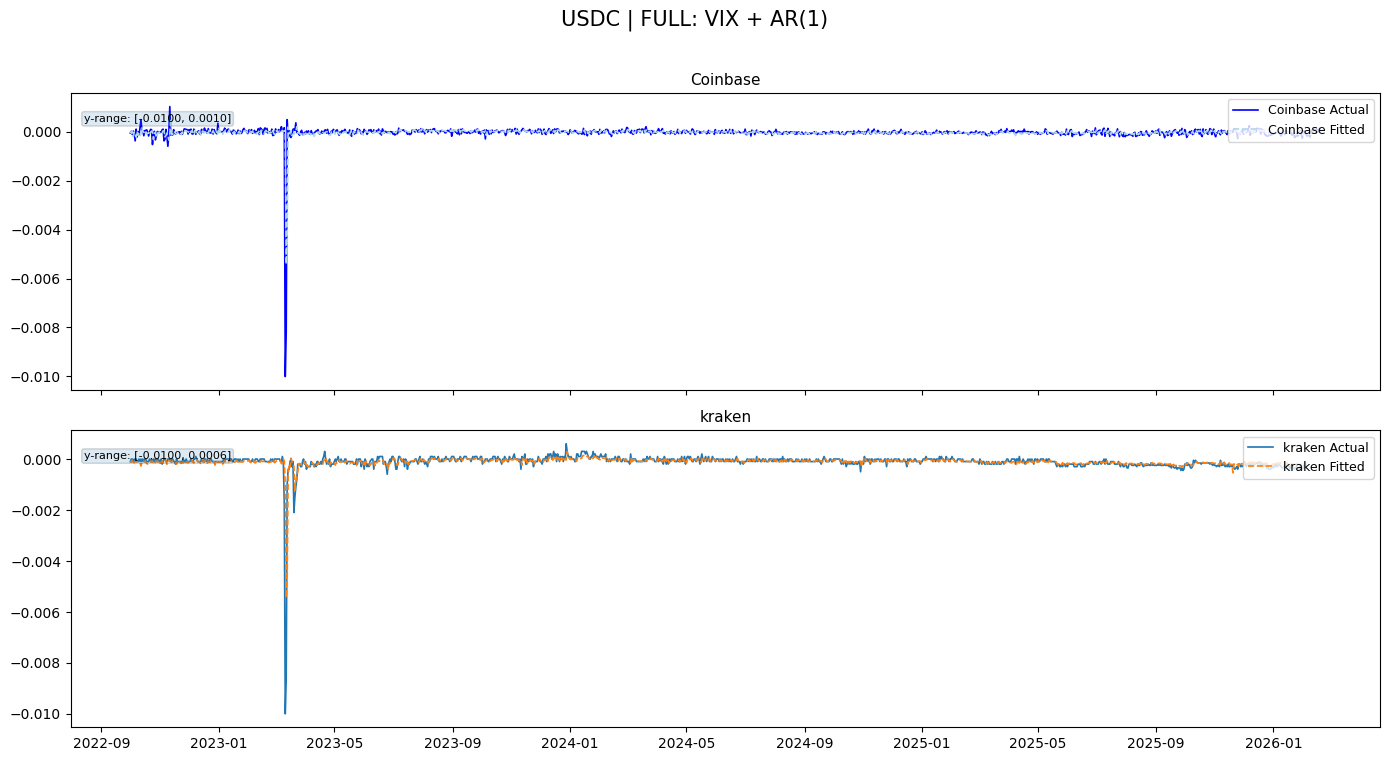

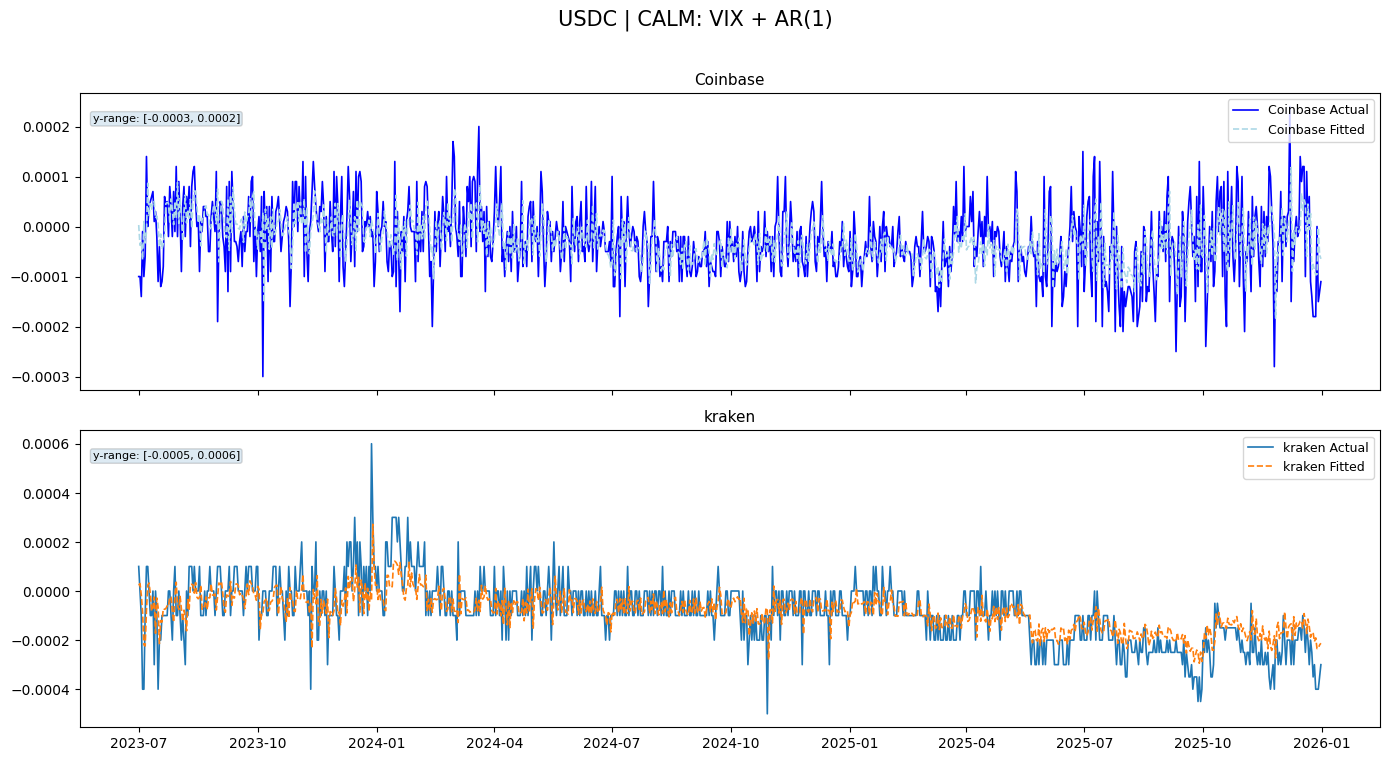

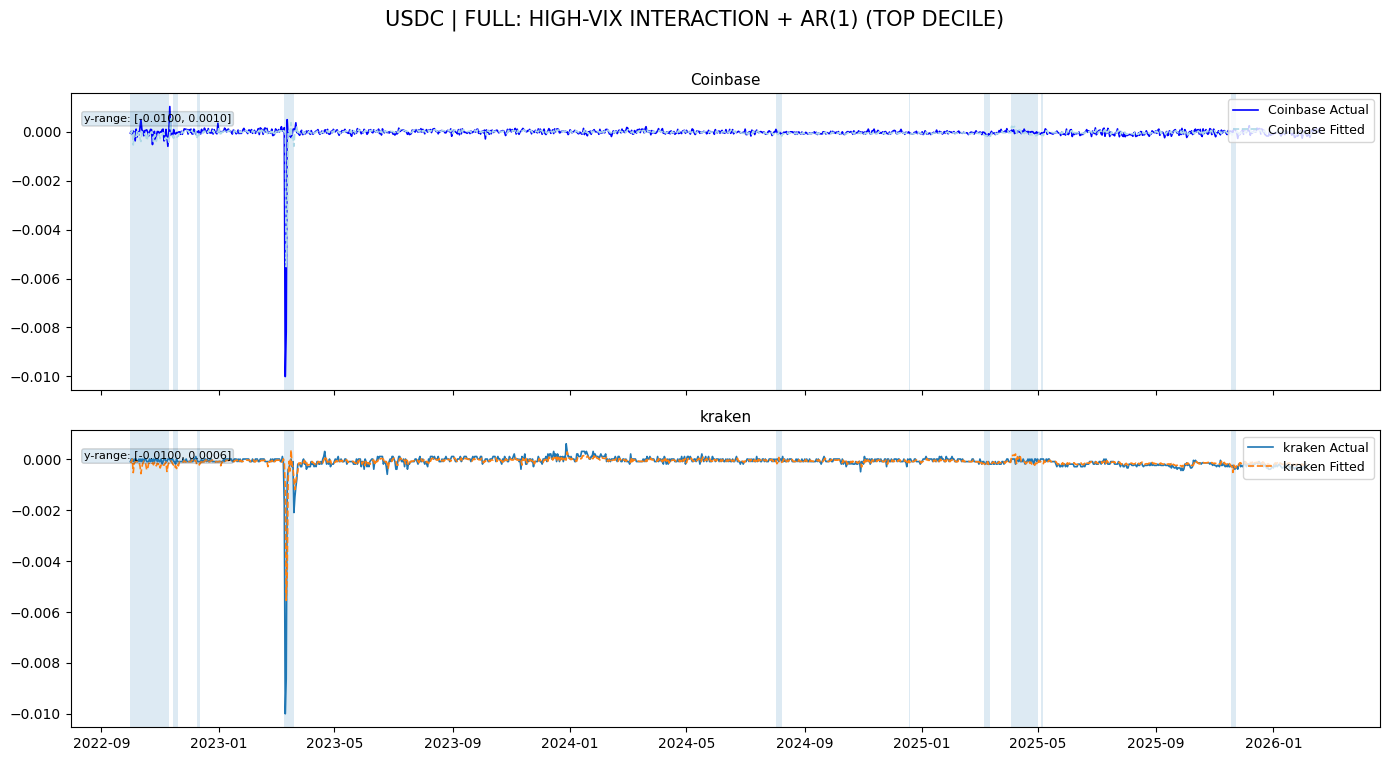

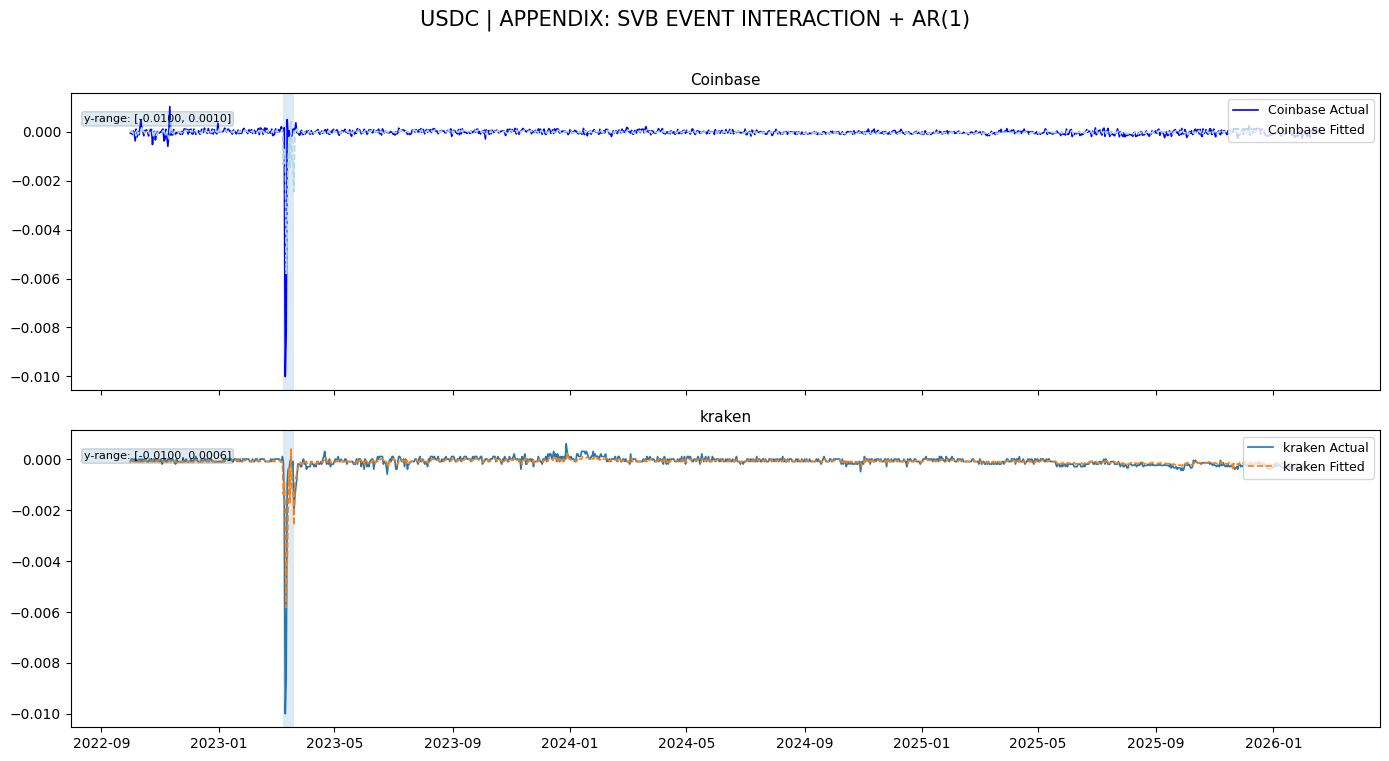

In [ ]:
def _fit_main_and_attach(data, separate_lk=False):
    """
    Exact fit for run_fe_main_paper:
      y ~ [safety OR zL,zK] + vix + hl_lag1 + vol_lag1 + FE + AR(1)
    Returns fitted dataframe and res.
    """
    required = ["y", "exchange", "date", "L", "K", "vix", "hl_lag1", "vol_lag1", "y_lag1"]
    d = data.dropna(subset=required).copy()
    if len(d) == 0:
        return None, None

    d, rhs = build_regressors_in_sample(d, include_vix=True, separate_lk=separate_lk)

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = d[rhs].astype(float)
    X = pd.concat([d[["y_lag1"]].astype(float), X], axis=1)
    X = pd.concat([X, ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = d["y"].astype(float)

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    d["y_hat"] = res.fittedvalues
    d["resid"] = d["y"] - d["y_hat"]
    return d, res


def _fit_stress_and_attach(data, stress_col, separate_lk=False):
    """
    Exact fit for run_fe_stress_interaction_paper:
      Composite:
        y ~ safety + vix_c + stress + safety*stress + vix_c*stress + micro + FE + AR1
      Separate:
        y ~ zL + zK + vix_c + stress + zL*stress + zK*stress + vix_c*stress + micro + FE + AR1
    Returns fitted dataframe and res.
    """
    required = ["y", "exchange", "date", "L", "K", "vix", stress_col, "hl_lag1", "vol_lag1", "y_lag1"]
    d = data.dropna(subset=required).copy()
    if len(d) == 0:
        return None, None

    d["zL"] = zscore_in_sample(d, "L")
    d["zK"] = zscore_in_sample(d, "K")
    d["vix_c"] = d["vix"] - d["vix"].mean()
    d["stress"] = d[stress_col].astype(int)

    if separate_lk:
        d["zL_x_stress"]   = d["zL"] * d["stress"]
        d["zK_x_stress"]   = d["zK"] * d["stress"]
        d["vixc_x_stress"] = d["vix_c"] * d["stress"]
        rhs = ["zL", "zK", "vix_c", "stress", "zL_x_stress", "zK_x_stress", "vixc_x_stress", "hl_lag1", "vol_lag1"]
    else:
        d["safety"] = d["zL"] + d["zK"]
        d["safety_x_stress"] = d["safety"] * d["stress"]
        d["vixc_x_stress"]   = d["vix_c"] * d["stress"]
        rhs = ["safety", "vix_c", "stress", "safety_x_stress", "vixc_x_stress", "hl_lag1", "vol_lag1"]

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = d[rhs].astype(float)
    X = pd.concat([d[["y_lag1"]].astype(float), X], axis=1)
    X = pd.concat([X, ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = d["y"].astype(float)

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    d["y_hat"] = res.fittedvalues
    d["resid"] = d["y"] - d["y_hat"]
    return d, res


def _normalize_exchange_name(ex):
    exs = str(ex).lower().strip()
    if "coinbase" in exs:
        return "coinbase"
    if "binance" in exs:
        return "binance"
    if ("crypto.com" in exs) or ("cryptocom" in exs) or ("cdc" in exs):
        return "crypto.com"
    return exs


def _shade_stress_blocks_global(ax, d):
    """Shade contiguous stress==1 windows using date-level max stress across exchanges."""
    if ("stress" not in d.columns) or d.empty:
        return

    s = (
        d[["date", "stress"]]
        .dropna()
        .groupby("date", as_index=False)["stress"].max()
        .sort_values("date")
    )
    if s.empty:
        return

    dates = s["date"].to_numpy()
    vals  = s["stress"].astype(int).to_numpy()

    in_block = False
    start_dt = None
    for i in range(len(vals)):
        if vals[i] == 1 and not in_block:
            in_block = True
            start_dt = dates[i]
        is_last = (i == len(vals) - 1)
        if in_block and (is_last or vals[i + 1] == 0):
            end_dt = dates[i]
            ax.axvspan(start_dt, end_dt, alpha=0.15)
            in_block = False
            start_dt = None


def _plot_actual_vs_fitted_stacked_exchanges(
    d, label, shade_stress=False, sharey=False, annotate_range=True,
    save_path=None, dpi=300
):
    if d is None or d.empty:
        print(f"❌ No data to plot for {label}")
        return

    color_map = {
        "coinbase":   {"actual": "blue",   "fitted": "lightblue", "disp": "Coinbase"},
        "binance":    {"actual": "orange", "fitted": "yellow",    "disp": "Binance"},
        "crypto.com": {"actual": "purple", "fitted": "pink",      "disp": "Crypto.com"},
    }

    d = d.copy()
    d["exchange_plot"] = d["exchange"].map(_normalize_exchange_name)

    preferred_order = ["coinbase", "binance", "crypto.com"]
    present = [ex for ex in preferred_order if ex in set(d["exchange_plot"].dropna())]
    others = [ex for ex in sorted(set(d["exchange_plot"].dropna())) if ex not in preferred_order]
    plot_order = present + others

    if len(plot_order) == 0:
        print(f"❌ No recognized exchanges to plot for {label}")
        return

    fig, axes = plt.subplots(
        nrows=len(plot_order),
        ncols=1,
        figsize=(14, 3.8 * len(plot_order)),
        sharex=True,
        sharey=sharey
    )
    if len(plot_order) == 1:
        axes = [axes]

    for ax, ex in zip(axes, plot_order):
        sub = d[d["exchange_plot"] == ex].sort_values("date")
        if sub.empty:
            continue

        if ex in color_map:
            c_actual = color_map[ex]["actual"]
            c_fitted = color_map[ex]["fitted"]
            disp     = color_map[ex]["disp"]
        else:
            c_actual = None
            c_fitted = None
            disp     = ex

        if shade_stress:
            _shade_stress_blocks_global(ax, d)

        ax.plot(sub["date"], sub["y"], label=f"{disp} Actual", linewidth=1.2, color=c_actual)
        ax.plot(sub["date"], sub["y_hat"], label=f"{disp} Fitted", linewidth=1.2, linestyle="--", color=c_fitted)

        ax.set_title(disp, fontsize=11)
        ax.legend(loc="upper right", fontsize=9)

        if annotate_range:
            y0 = np.nanmin(np.r_[sub["y"].to_numpy(), sub["y_hat"].to_numpy()])
            y1 = np.nanmax(np.r_[sub["y"].to_numpy(), sub["y_hat"].to_numpy()])
            ax.text(
                0.01, 0.93,
                f"y-range: [{y0:.4f}, {y1:.4f}]",
                transform=ax.transAxes,
                fontsize=8,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.2", alpha=0.15)
            )

    fig.suptitle(label, fontsize=15, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")

    plt.show()


# 1) FULL: VIX + AR(1)
fit_full_main_df, fit_full_main_res = _fit_main_and_attach(df_full, separate_lk=SEPARATE_LK)
_plot_actual_vs_fitted_stacked_exchanges(
    fit_full_main_df,
    f"{COIN_LABEL} | FULL: VIX + AR(1)",
    shade_stress=False,
    sharey=False,
    annotate_range=True
)

# 2) CALM: VIX + AR(1)
fit_calm_main_df, fit_calm_main_res = _fit_main_and_attach(df_calm, separate_lk=SEPARATE_LK)
_plot_actual_vs_fitted_stacked_exchanges(
    fit_calm_main_df,
    f"{COIN_LABEL} | CALM: VIX + AR(1)",
    shade_stress=False,
    sharey=False,
    annotate_range=True
)

# 3) FULL: HIGH-VIX INTERACTION + AR(1)
if USE_HIGH_VIX_STRESS:
    fit_stress_vix_df, fit_stress_vix_res = _fit_stress_and_attach(df_full, "stress_vix", separate_lk=SEPARATE_LK)
    _plot_actual_vs_fitted_stacked_exchanges(
        fit_stress_vix_df,
        f"{COIN_LABEL} | FULL: HIGH-VIX INTERACTION + AR(1) (TOP DECILE)",
        shade_stress=True,
        sharey=False,
        annotate_range=True
    )
else:
    fit_stress_vix_df, fit_stress_vix_res = None, None
    print("High-VIX stress disabled (USE_HIGH_VIX_STRESS=False).")

# 4) FULL: SVB EVENT INTERACTION + AR(1) [appendix]
if RUN_SVB_EVENT_APPENDIX:
    fit_stress_event_df, fit_stress_event_res = _fit_stress_and_attach(df_full, "stress_event", separate_lk=SEPARATE_LK)
    _plot_actual_vs_fitted_stacked_exchanges(
        fit_stress_event_df,
        f"{COIN_LABEL} | APPENDIX: SVB EVENT INTERACTION + AR(1)",
        shade_stress=True,
        sharey=False,
        annotate_range=True
    )
else:
    fit_stress_event_df, fit_stress_event_res = None, None
    print("SVB appendix disabled (RUN_SVB_EVENT_APPENDIX=False).")

✅ Saved: figures/main/usdc_full_vix_ar1.png


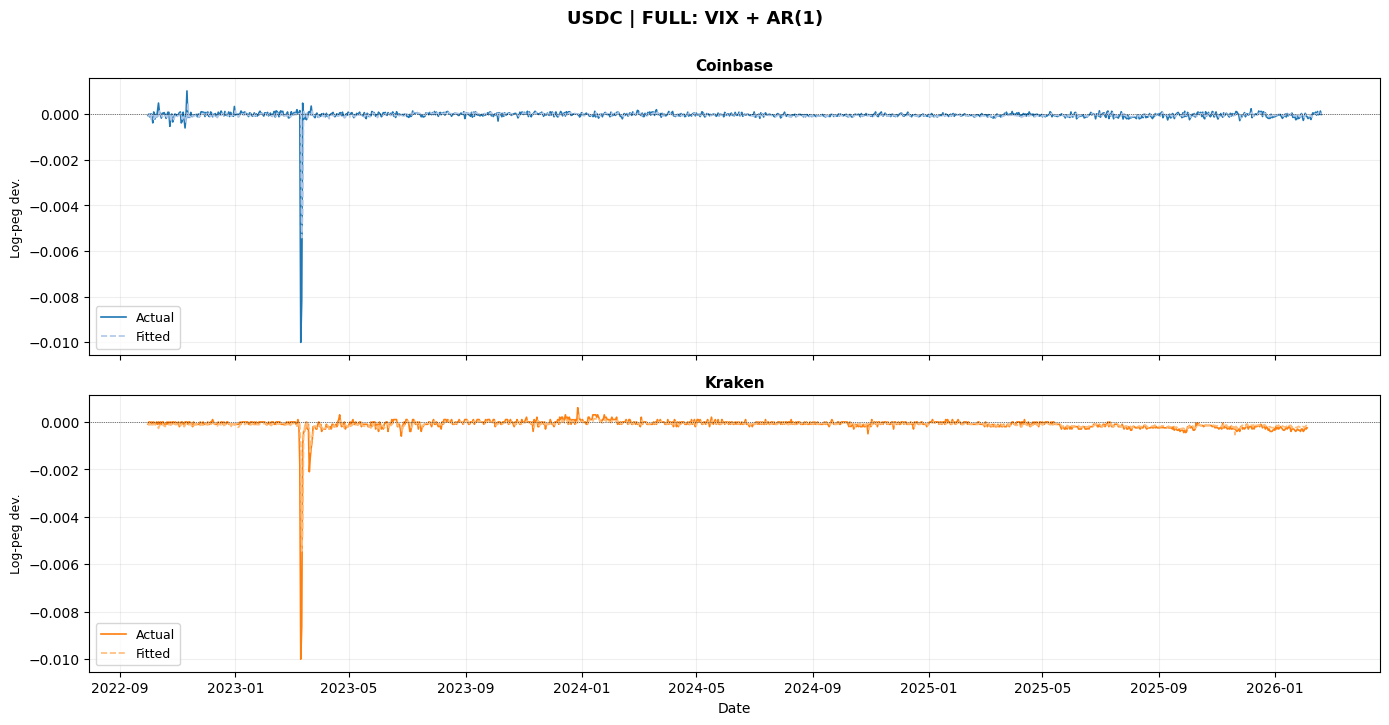

✅ Saved: figures/main/usdc_calm_vix_ar1.png


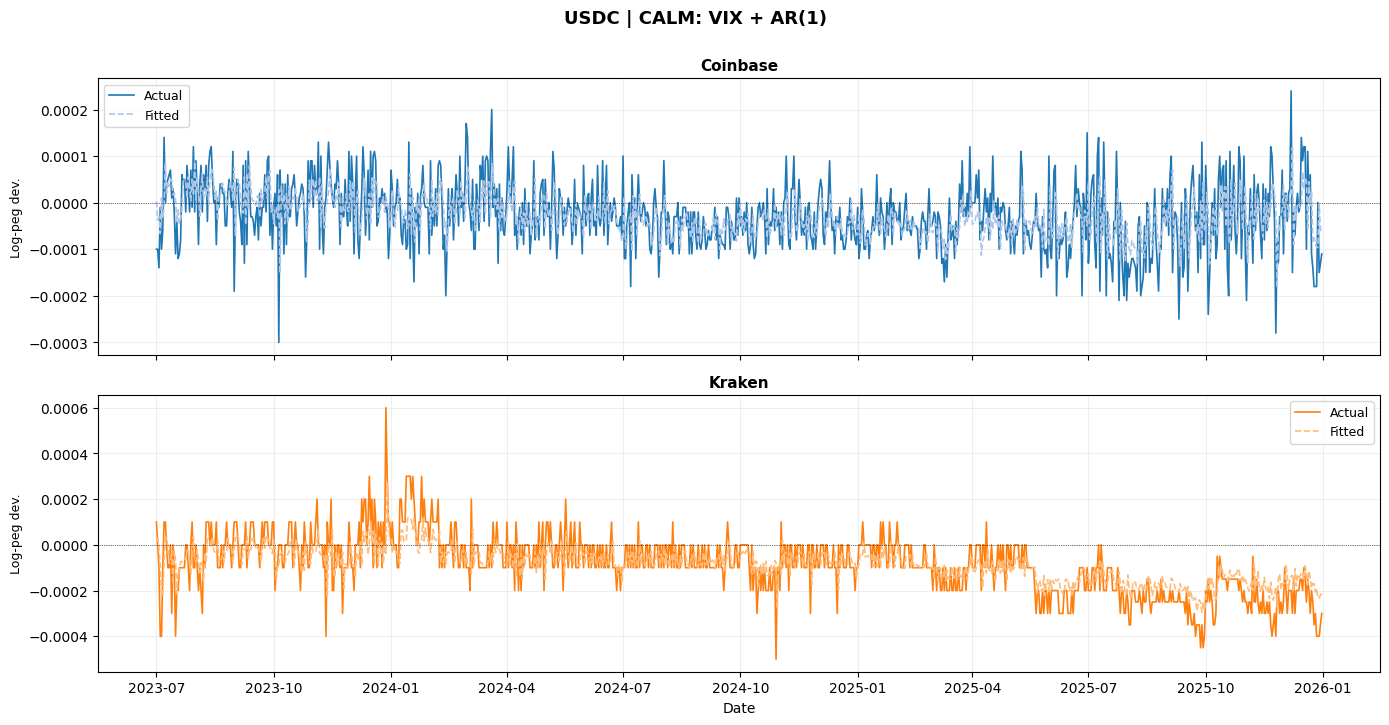

✅ Saved: figures/appendix/usdc_highvix_fullsample_context.png


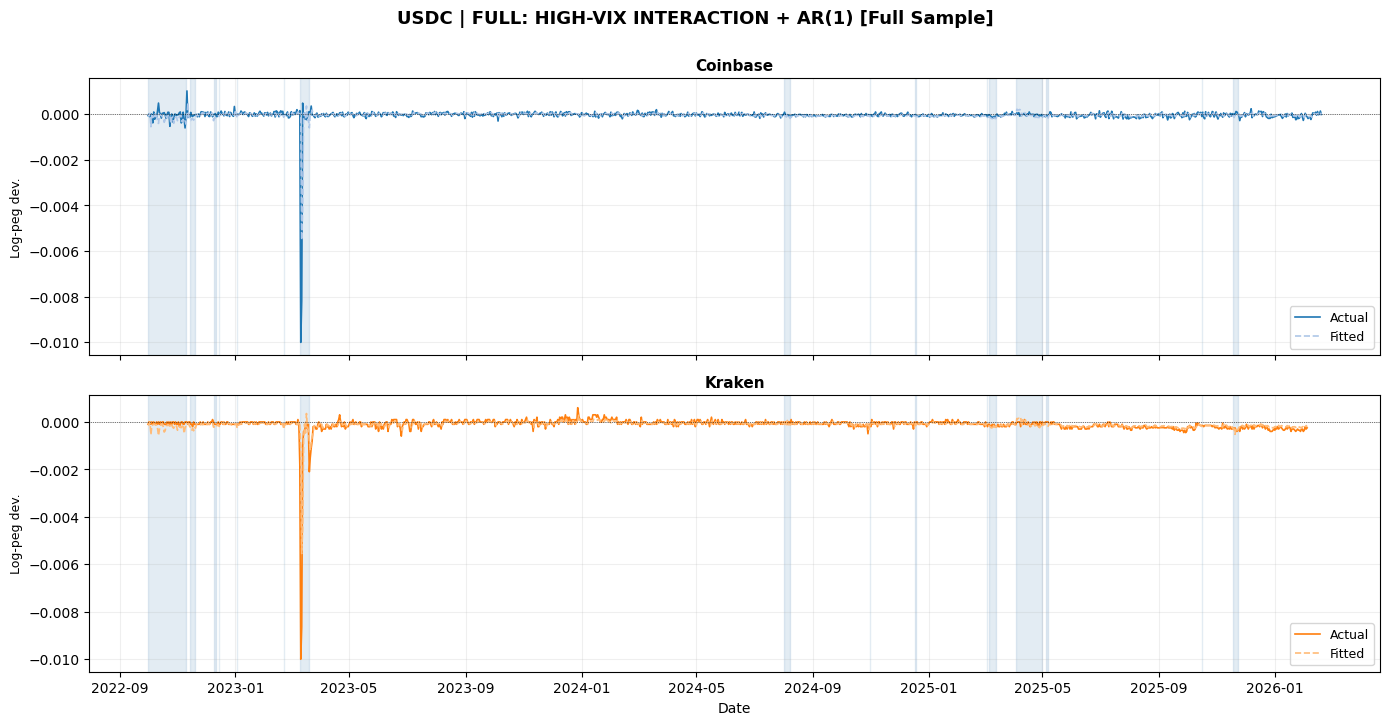

High-VIX blocks found: 12
  2022-09-24 → 2022-11-27
  2022-12-02 → 2022-12-22
  2022-12-27 → 2023-01-10
  2023-02-14 → 2023-02-28
  2023-03-03 → 2023-03-27
  2024-07-26 → 2024-08-15
  2024-10-24 → 2024-11-07
  2024-12-11 → 2024-12-26
  2025-02-25 → 2025-03-20
  2025-03-27 → 2025-05-14
  2025-10-09 → 2025-10-23
  2025-11-11 → 2025-11-30


C:\Users\borto\AppData\Local\Temp\ipykernel_31900\1495709107.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: figures/appendix/usdc_highvix_stress_windows.png


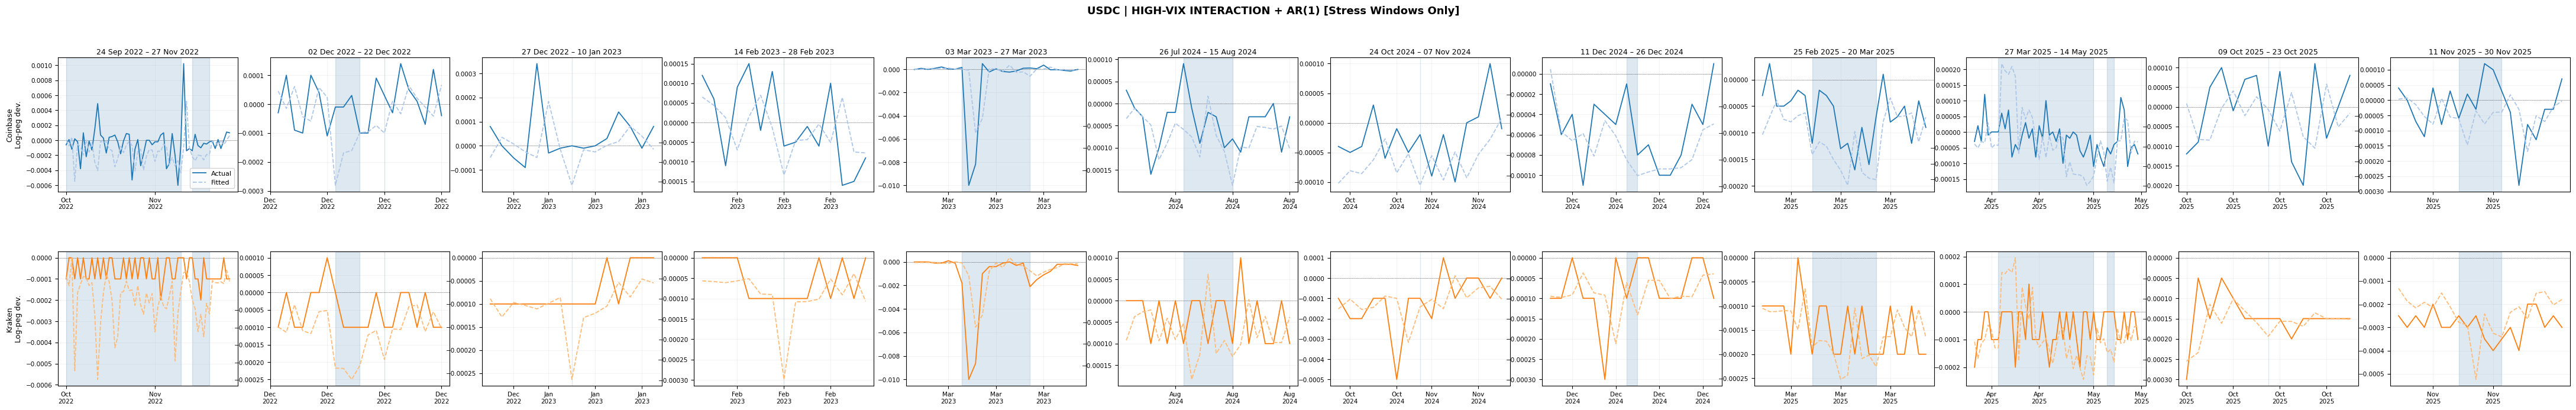

✅ Saved: figures/appendix/usdc_svb_fullsample_context.png


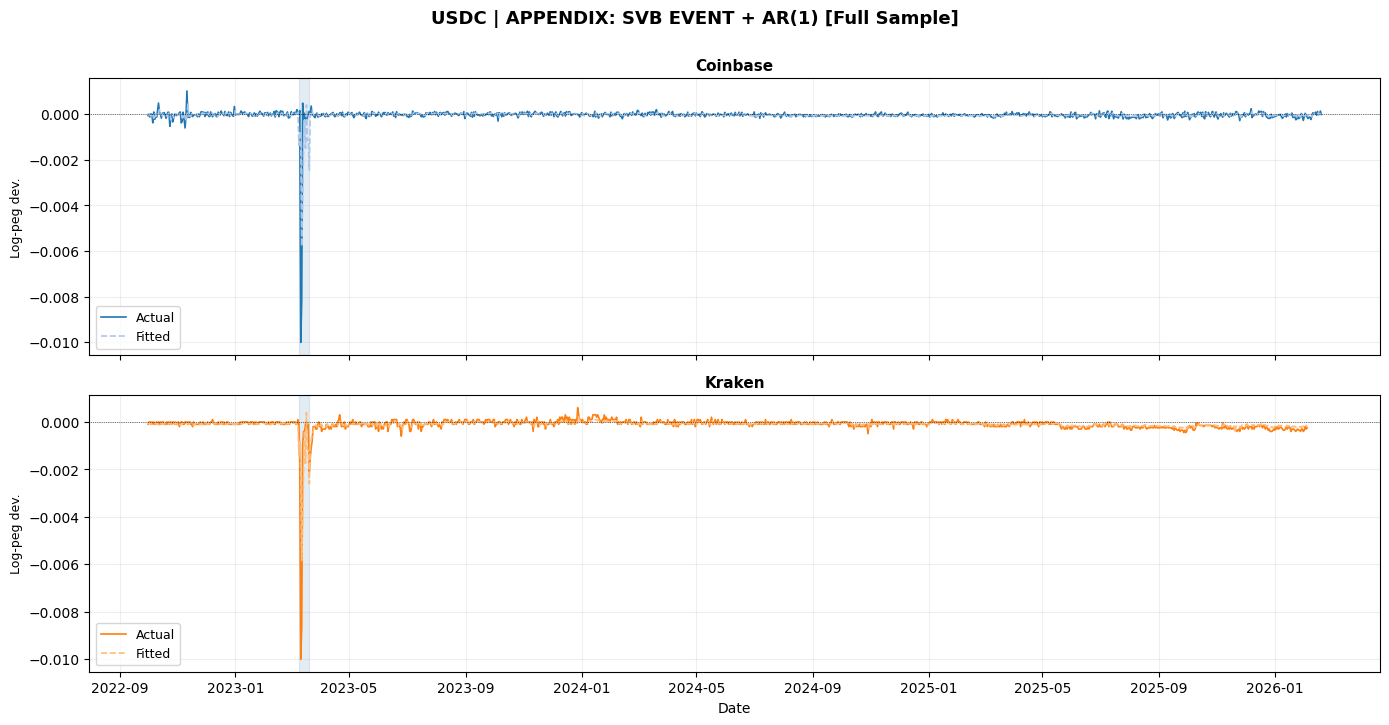

C:\Users\borto\AppData\Local\Temp\ipykernel_31900\1495709107.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: figures/appendix/usdc_svb_march2023_zoom.png


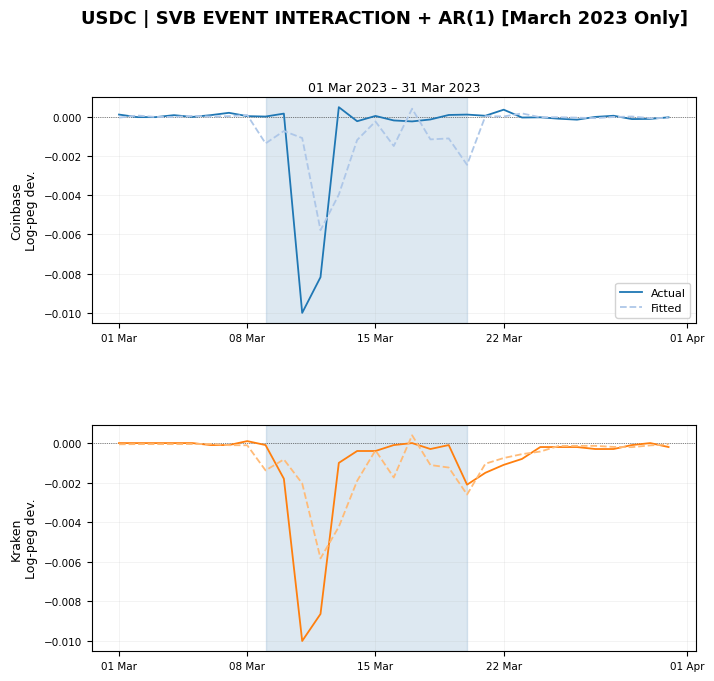

In [ ]:
# (A) STRESS BLOCK EXTRACTOR
def _get_stress_blocks(d, gap_threshold_days=14, buffer_days=7):
    """
    Find contiguous stress==1 date ranges, merge nearby blocks
    (within gap_threshold_days), then expand by buffer_days.
    Returns list of (start, end) Timestamps.
    """
    if d is None or d.empty or "stress" not in d.columns:
        return []

    tmp = (d[["date", "stress"]].dropna()
             .assign(date=lambda x: pd.to_datetime(x["date"]))
             .groupby("date", as_index=False)["stress"].max())
    stress_dates = tmp.loc[tmp["stress"] == 1, "date"].sort_values().reset_index(drop=True)

    if len(stress_dates) == 0:
        return []

    gap = pd.Timedelta(days=gap_threshold_days)
    buf = pd.Timedelta(days=buffer_days)

    blocks = []
    b_start = stress_dates.iloc[0]
    b_end   = stress_dates.iloc[0]

    for dt in stress_dates.iloc[1:]:
        if dt - b_end <= gap:
            b_end = dt
        else:
            blocks.append((b_start - buf, b_end + buf))
            b_start = dt
            b_end   = dt
    blocks.append((b_start - buf, b_end + buf))

    return blocks


def _fixed_window_blocks(x_start, x_end):
    """Single fixed window (e.g. SVB)."""
    return [(pd.Timestamp(x_start), pd.Timestamp(x_end))]


# (B) FIT HELPERS (unchanged from regression code)
def _fit_main_and_attach(data, separate_lk=False):
    required = ["y", "exchange", "date", "L", "K", "vix", "hl_lag1", "vol_lag1", "y_lag1"]
    d = data.dropna(subset=required).copy()
    if len(d) == 0:
        return None, None
    d, rhs = build_regressors_in_sample(d, include_vix=True, separate_lk=separate_lk)
    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = pd.concat([d[["y_lag1"]].astype(float), d[rhs].astype(float), ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    res = sm.OLS(d["y"].astype(float), X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    d["y_hat"] = res.fittedvalues
    return d, res


def _fit_stress_and_attach(data, stress_col, separate_lk=False):
    required = ["y", "exchange", "date", "L", "K", "vix", stress_col,
                "hl_lag1", "vol_lag1", "y_lag1"]
    d = data.dropna(subset=required).copy()
    if len(d) == 0:
        return None, None
    d["zL"]    = zscore_in_sample(d, "L")
    d["zK"]    = zscore_in_sample(d, "K")
    d["vix_c"] = d["vix"] - d["vix"].mean()
    d["stress"] = d[stress_col].astype(int)

    if separate_lk:
        d["zL_x_stress"]   = d["zL"]  * d["stress"]
        d["zK_x_stress"]   = d["zK"]  * d["stress"]
        d["vixc_x_stress"] = d["vix_c"] * d["stress"]
        rhs = ["zL", "zK", "vix_c", "stress",
                "zL_x_stress", "zK_x_stress", "vixc_x_stress",
                "hl_lag1", "vol_lag1"]
    else:
        d["safety"]          = d["zL"] + d["zK"]
        d["safety_x_stress"] = d["safety"] * d["stress"]
        d["vixc_x_stress"]   = d["vix_c"]  * d["stress"]
        rhs = ["safety", "vix_c", "stress",
                "safety_x_stress", "vixc_x_stress",
                "hl_lag1", "vol_lag1"]

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = pd.concat([d[["y_lag1"]].astype(float), d[rhs].astype(float), ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    res = sm.OLS(d["y"].astype(float), X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    d["y_hat"] = res.fittedvalues
    return d, res


# (C) NORMALIZE EXCHANGE NAMES
def _normalize_exchange_name(ex):
    exs = str(ex).lower().strip()
    if "coinbase"  in exs: return "coinbase"
    if "binance"   in exs: return "binance"
    if ("crypto.com" in exs) or ("cryptocom" in exs) or ("cdc" in exs): return "crypto.com"
    if "kraken"    in exs: return "kraken"
    return exs

COLOR_MAP = {
    "coinbase":   {"actual": "#1f77b4", "fitted": "#aec7e8", "disp": "Coinbase"},
    "kraken":     {"actual": "#ff7f0e", "fitted": "#ffbb78", "disp": "Kraken"},
    "binance":    {"actual": "#d62728", "fitted": "#ff9896", "disp": "Binance"},
    "crypto.com": {"actual": "#9467bd", "fitted": "#c5b0d5", "disp": "Crypto.com"},
}

PREFERRED_ORDER = ["coinbase", "kraken", "binance", "crypto.com"]


# (D) CORE ZOOM PLOT — one column per stress block-
def plot_stress_windows(
    d,
    label,
    blocks,                  # list of (start_ts, end_ts) — from _get_stress_blocks
    shade_stress=True,       # shade stress==1 within each window
    sharey_cols=False,       # share y-axis across stress blocks (same row)
    sharey_rows=False,       # share y-axis across exchanges (same block)
    save_path=None,
    dpi=300,
    row_height=3.2,
    col_width=4.5,
    date_fmt="%b\n%Y",
    max_date_ticks=5,
):
    """
    TRUE ZOOM PLOT.
    Rows    = exchanges
    Columns = stress blocks (non-stress dates completely absent)

    Each cell shows actual vs fitted for one exchange in one stress window.
    """
    if d is None or d.empty:
        print(f"❌ No data: {label}")
        return

    d = d.copy()
    d["date"]          = pd.to_datetime(d["date"])
    d["exchange_plot"] = d["exchange"].map(_normalize_exchange_name)

    present    = [e for e in PREFERRED_ORDER if e in set(d["exchange_plot"].dropna())]
    others     = [e for e in sorted(set(d["exchange_plot"].dropna())) if e not in PREFERRED_ORDER]
    exchanges  = present + others
    n_exc      = len(exchanges)
    n_blocks   = len(blocks)

    if n_exc == 0 or n_blocks == 0:
        print(f"❌ No exchanges or stress blocks for: {label}")
        return

    fig_w = col_width * n_blocks + 0.8
    fig_h = row_height * n_exc   + 0.8

    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.suptitle(label, fontsize=13, fontweight="bold", y=1.002)

    gs = GridSpec(
        n_exc, n_blocks,
        figure=fig,
        hspace=0.45,
        wspace=0.18,
    )

    # Track axes for shared-y logic
    axes_grid = {}   # (row, col) -> ax

    for ci, (b_start, b_end) in enumerate(blocks):
        block_data = d[(d["date"] >= b_start) & (d["date"] <= b_end)].copy()

        for ri, ex in enumerate(exchanges):
            share_y_ax = None
            if sharey_cols and ri > 0:
                share_y_ax = axes_grid.get((0, ci))
            if sharey_rows and ci > 0:
                share_y_ax = axes_grid.get((ri, 0))

            ax = fig.add_subplot(gs[ri, ci], sharey=share_y_ax)
            axes_grid[(ri, ci)] = ax

            sub = block_data[block_data["exchange_plot"] == ex].sort_values("date")
            cm  = COLOR_MAP.get(ex, {"actual": "black", "fitted": "grey", "disp": ex})

            if sub.empty:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", va="center", color="grey", fontsize=9)
            else:
                if shade_stress and "stress" in sub.columns:
                    stress_rows = sub[sub["stress"] == 1]
                    if not stress_rows.empty:
                        s_dates = stress_rows["date"].sort_values()
                        # find contiguous runs
                        gaps  = s_dates.diff() > pd.Timedelta(days=2)
                        run_s = s_dates[gaps | (s_dates == s_dates.iloc[0])]
                        run_e = s_dates[gaps.shift(-1, fill_value=True)]
                        for rs, re in zip(run_s, run_e):
                            ax.axvspan(rs, re, alpha=0.18,
                                       color="steelblue", zorder=0)

                ax.plot(sub["date"], sub["y"],
                        color=cm["actual"], linewidth=1.3,
                        label="Actual", zorder=2)
                ax.plot(sub["date"], sub["y_hat"],
                        color=cm["fitted"], linewidth=1.3,
                        linestyle="--", label="Fitted", zorder=2)
                ax.axhline(0, color="black", linewidth=0.5,
                           linestyle=":", zorder=1)
                ax.grid(True, alpha=0.2, linewidth=0.5)

            if ri == 0:
                col_title = f"{b_start.strftime('%d %b %Y')} – {b_end.strftime('%d %b %Y')}"
                ax.set_title(col_title, fontsize=9, pad=4)

            if ci == 0:
                ax.set_ylabel(cm["disp"] + "\nLog-peg dev.", fontsize=9)
            else:
                ax.set_ylabel("")

            if ri == 0 and ci == 0 and not sub.empty:
                ax.legend(fontsize=8, frameon=True, framealpha=0.85,
                          loc="lower right")

            ax.xaxis.set_major_locator(
                mdates.AutoDateLocator(minticks=2, maxticks=max_date_ticks))
            ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
            ax.tick_params(axis="x", labelsize=7.5)
            ax.tick_params(axis="y", labelsize=7.5)

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")

    plt.show()


# (E) FULL-SAMPLE PLOT (unchanged, used for context/appendix)
def plot_full_sample(
    d, label,
    shade_stress=False,
    sharey=False,
    save_path=None,
    dpi=300,
    fig_width=14,
    row_height=3.6,
):
    if d is None or d.empty:
        print(f"❌ No data: {label}")
        return

    d = d.copy()
    d["date"]          = pd.to_datetime(d["date"])
    d["exchange_plot"] = d["exchange"].map(_normalize_exchange_name)

    present   = [e for e in PREFERRED_ORDER if e in set(d["exchange_plot"].dropna())]
    others    = [e for e in sorted(set(d["exchange_plot"].dropna())) if e not in PREFERRED_ORDER]
    plot_order = present + others

    fig, axes = plt.subplots(
        nrows=len(plot_order), ncols=1,
        figsize=(fig_width, row_height * len(plot_order)),
        sharex=True, sharey=sharey,
    )
    if len(plot_order) == 1:
        axes = [axes]

    def _shade(ax, df_):
        if "stress" not in df_.columns or df_.empty:
            return
        s = (df_[["date","stress"]].dropna()
               .groupby("date", as_index=False)["stress"].max()
               .sort_values("date"))
        dates = s["date"].to_numpy()
        vals  = s["stress"].astype(int).to_numpy()
        in_b  = False
        for i in range(len(vals)):
            if vals[i] == 1 and not in_b:
                in_b = True; sd = dates[i]
            if in_b and (i == len(vals)-1 or vals[i+1] == 0):
                ax.axvspan(sd, dates[i], alpha=0.15, color="steelblue")
                in_b = False

    for ax, ex in zip(axes, plot_order):
        sub = d[d["exchange_plot"] == ex].sort_values("date")
        cm  = COLOR_MAP.get(ex, {"actual": "black", "fitted": "grey", "disp": ex})
        if shade_stress:
            _shade(ax, sub)
        if not sub.empty:
            ax.plot(sub["date"], sub["y"],     color=cm["actual"], linewidth=1.2, label="Actual")
            ax.plot(sub["date"], sub["y_hat"], color=cm["fitted"], linewidth=1.2, linestyle="--", label="Fitted")
            ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
        ax.set_ylabel("Log-peg dev.", fontsize=9)
        ax.set_title(cm["disp"], fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=9, frameon=True)

    axes[-1].set_xlabel("Date")
    fig.suptitle(label, fontsize=13, fontweight="bold", y=1.001)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")

    plt.show()


# (F) RUN ALL PLOTS  [UPDATED: with save paths]
os.makedirs("figures/main", exist_ok=True)
os.makedirs("figures/appendix", exist_ok=True)

coin_tag = str(COIN_LABEL).lower().replace(" ", "_")

# ── 1) FULL SAMPLE: VIX + AR(1) ──────────────────────────
fit_full_main_df, fit_full_main_res = _fit_main_and_attach(
    df_full, separate_lk=SEPARATE_LK)

plot_full_sample(
    fit_full_main_df,
    f"{COIN_LABEL} | FULL: VIX + AR(1)",
    shade_stress=False,
    save_path=f"figures/main/{coin_tag}_full_vix_ar1.png",   # <- save
    dpi=300,
)

# ── 2) CALM: VIX + AR(1) ─────────────────────────────────
fit_calm_main_df, fit_calm_main_res = _fit_main_and_attach(
    df_calm, separate_lk=SEPARATE_LK)

plot_full_sample(
    fit_calm_main_df,
    f"{COIN_LABEL} | CALM: VIX + AR(1)",
    shade_stress=False,
    save_path=f"figures/main/{coin_tag}_calm_vix_ar1.png",
    dpi=300,
)

# ── 3) HIGH-VIX INTERACTION ───────────────────────────────
if USE_HIGH_VIX_STRESS:
    fit_stress_vix_df, fit_stress_vix_res = _fit_stress_and_attach(
        df_full, "stress_vix", separate_lk=SEPARATE_LK)

    plot_full_sample(
        fit_stress_vix_df,
        f"{COIN_LABEL} | FULL: HIGH-VIX INTERACTION + AR(1) [Full Sample]",
        shade_stress=True,
        save_path=f"figures/appendix/{coin_tag}_highvix_fullsample_context.png",
        dpi=300,
    )

    # ★ TRUE ZOOM — only high-VIX blocks, non-stress dates removed ★
    vix_blocks = _get_stress_blocks(
        fit_stress_vix_df,
        gap_threshold_days=14,
        buffer_days=7,       =
    )
    print(f"High-VIX blocks found: {len(vix_blocks)}")
    for b in vix_blocks:
        print(f"  {b[0].date()} → {b[1].date()}")

    plot_stress_windows(
        fit_stress_vix_df,
        f"{COIN_LABEL} | HIGH-VIX INTERACTION + AR(1) [Stress Windows Only]",
        blocks=vix_blocks,
        shade_stress=True,
        sharey_cols=False,
        sharey_rows=False,
        row_height=3.2,
        save_path=f"figures/appendix/{coin_tag}_highvix_stress_windows.png",
        dpi=300,
    )
else:
    fit_stress_vix_df = None
    print("High-VIX stress disabled.")

# ── 4) SVB EVENT INTERACTION ──────────────────────────────
if RUN_SVB_EVENT_APPENDIX:
    fit_stress_event_df, fit_stress_event_res = _fit_stress_and_attach(
        df_full, "stress_event", separate_lk=SEPARATE_LK)

    plot_full_sample(
        fit_stress_event_df,
        f"{COIN_LABEL} | APPENDIX: SVB EVENT + AR(1) [Full Sample]",
        shade_stress=True,
        save_path=f"figures/appendix/{coin_tag}_svb_fullsample_context.png",
        dpi=300,
    )

    svb_blocks = _fixed_window_blocks("2023-03-01", "2023-03-31")

    plot_stress_windows(
        fit_stress_event_df,
        f"{COIN_LABEL} | SVB EVENT INTERACTION + AR(1) [March 2023 Only]",
        blocks=svb_blocks,
        shade_stress=True,
        col_width=7,
        row_height=3.2,
        date_fmt="%d %b",
        max_date_ticks=8,
        save_path=f"figures/appendix/{coin_tag}_svb_march2023_zoom.png",
        dpi=300,
    )
else:
    fit_stress_event_df = None
    print("SVB appendix disabled.")

## USDT

In [ ]:
FILE        = "USDTReg.xlsx"
DAILY_SHEET = "USDTDaily"
BS_SHEET    = "Tether"

COIN_LABEL = "USDT"

START_DATE = "2022-09-30"
HAC_LAGS   = 7

# Calm subsample (paper main)
CALM_START = "2023-07-01"
CALM_END   = "2025-12-31"

# Stress definitions
STRESS_EVENT_START = "2023-03-09"
STRESS_EVENT_END   = "2023-03-20"

USE_HIGH_VIX_STRESS = True          # paper main stress definition
HIGH_VIX_Q          = 0.90

# Keep SVB event-window interaction as appendix-only robustness
RUN_SVB_EVENT_APPENDIX = True

WINSORIZE_Y = True
WINSOR_LO_Q = 0.001   # 0.1%
WINSOR_HI_Q = 0.999   # 99.9%


daily = pd.read_excel(FILE, sheet_name=DAILY_SHEET)
bs    = pd.read_excel(FILE, sheet_name=BS_SHEET)
daily["date"] = pd.to_datetime(daily["date"], errors="coerce").dt.tz_localize(None).dt.normalize()
bs["Date"]    = pd.to_datetime(bs["Date"], errors="coerce").dt.tz_localize(None).dt.normalize()
bs = bs.rename(columns={"Date": "date"})


keep_cols = ["date", "L", "K", "VIX"]
missing_bs = [c for c in keep_cols if c not in bs.columns]
if missing_bs:
    raise ValueError(f"Missing required balance sheet columns in {BS_SHEET}: {missing_bs}")

df = daily.merge(bs[keep_cols], on="date", how="left")

df["exchange"] = df["exchange"].astype(str).str.lower().str.strip()
df = df[df["date"] >= pd.Timestamp(START_DATE)].copy()
df = df.sort_values(["exchange", "date"]).replace([np.inf, -np.inf], np.nan)


# Dependent variable (peg deviation)
df["y_raw"] = pd.to_numeric(df["log_peg"], errors="coerce")

# Microstructure controls
df["hl"]  = pd.to_numeric(df["hl_spread"], errors="coerce")
df["vol"] = np.log1p(pd.to_numeric(df["volume"], errors="coerce"))

# Balance sheet regressors
df["L"] = pd.to_numeric(df["L"], errors="coerce")
df["K"] = pd.to_numeric(df["K"], errors="coerce")

# Macro risk control
df["vix"] = pd.to_numeric(df["VIX"], errors="coerce")

# Microstructure lags (by exchange)
df["hl_lag1"]  = df.groupby("exchange")["hl"].shift(1)
df["vol_lag1"] = df.groupby("exchange")["vol"].shift(1)

# AR(1) lag (from raw first; overwritten after winsorization if enabled)
df["y_raw_lag1"] = df.groupby("exchange")["y_raw"].shift(1)


# A) Event window around SVB / USDC depeg (appendix robustness)
df["stress_event"] = (
    (df["date"] >= pd.Timestamp(STRESS_EVENT_START)) &
    (df["date"] <= pd.Timestamp(STRESS_EVENT_END))
).astype(int)

# B) High-VIX regime (paper main stress definition)
if USE_HIGH_VIX_STRESS:
    vix_cut = df["vix"].quantile(HIGH_VIX_Q)
    df["stress_vix"] = (df["vix"] >= vix_cut).astype(int)
else:
    vix_cut = np.nan
    df["stress_vix"] = 0

def winsorize_series(s, lo_q=WINSOR_LO_Q, hi_q=WINSOR_HI_Q):
    s = s.astype(float)
    lo = s.quantile(lo_q)
    hi = s.quantile(hi_q)
    return s.clip(lower=lo, upper=hi), lo, hi

df["y"] = df["y_raw"].copy()
df["y_lag1"] = df["y_raw_lag1"].copy()

if WINSORIZE_Y:
    y_w, lo, hi = winsorize_series(df["y"])
    df["y"] = y_w
    # recompute AR(1) lag from winsorized y for consistency
    df["y_lag1"] = df.groupby("exchange")["y"].shift(1)
    print(f"Winsorized y at [{WINSOR_LO_Q:.3%},{WINSOR_HI_Q:.3%}] quantiles: lo={lo:.6g}, hi={hi:.6g}")


print("\n==========================================================")
print("DIAGNOSTICS")
print("==========================================================")
print("Exchanges:", df["exchange"].dropna().unique())
if df["date"].notna().any():
    print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

core = ["y", "L", "K", "vix", "hl_lag1", "vol_lag1", "y_lag1", "stress_event", "stress_vix"]
print("\nNon-missing share (core vars):")
print(df[core].notna().mean().sort_values(ascending=False))

lk_nonmiss = df[["L", "K"]].dropna()
if len(lk_nonmiss) > 1:
    print("\nCorr(L,K) on non-missing rows:", lk_nonmiss.corr().iloc[0, 1])
else:
    print("\nCorr(L,K): not enough non-missing rows.")

if USE_HIGH_VIX_STRESS and np.isfinite(vix_cut):
    print(f"High-VIX cutoff (q={HIGH_VIX_Q:.0%}): {vix_cut:.4f}")


def zscore_in_sample(d, col):
    x = d[col].astype(float)
    m = x.mean()
    sd = x.std(ddof=0)
    if (sd is None) or (not np.isfinite(sd)) or (sd <= 0):
        return pd.Series(np.nan, index=d.index)
    return (x - m) / sd

def run_fe_main_paper_usdt(data, label, use_ar1=True):
    """
    USDT main paper spec (L and K separate):
      y ~ zL + zK + vix + hl_lag1 + vol_lag1 + FE + AR(1)
    zL/zK are built IN-SAMPLE (per regression sample).
    """
    required = ["y", "exchange", "date", "L", "K", "vix", "hl_lag1", "vol_lag1"]
    if use_ar1:
        required += ["y_lag1"]

    d = data.dropna(subset=required).copy()
    print("\n====================", label, "====================")
    if len(d) == 0:
        print("❌ 0 observations after dropna.")
        return None

    # In-sample z-scoring (USDT preferred)
    d["zL"] = zscore_in_sample(d, "L")
    d["zK"] = zscore_in_sample(d, "K")

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = d[["zL", "zK", "vix", "hl_lag1", "vol_lag1"]].astype(float)

    if use_ar1:
        X = pd.concat([d[["y_lag1"]].astype(float), X], axis=1)

    X = pd.concat([X, ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = d["y"].astype(float)

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    print("Obs:", len(d))
    print("Exchanges:", d["exchange"].unique())
    print("Date range:", d["date"].min().date(), "to", d["date"].max().date())
    print("Spec: SEPARATE zL,zK | VIX + AR(1)" if use_ar1 else "Spec: SEPARATE zL,zK | VIX")
    print(res.summary())
    return res

def run_fe_stress_interaction_paper_usdt(data, stress_col, label, use_ar1=True):
    """
    USDT stress interaction paper spec (L and K separate):
      y ~ zL + zK + vix_c + stress + zL*stress + zK*stress + vix_c*stress
          + hl_lag1 + vol_lag1 + FE + AR(1)
    zL/zK and centered vix_c are built IN-SAMPLE.
    """
    required = ["y", "exchange", "date", "L", "K", "vix", stress_col, "hl_lag1", "vol_lag1"]
    if use_ar1:
        required += ["y_lag1"]

    d = data.dropna(subset=required).copy()
    print("\n====================", label, "====================")
    if len(d) == 0:
        print("❌ 0 observations after dropna.")
        return None

    # In-sample z-scoring
    d["zL"] = zscore_in_sample(d, "L")
    d["zK"] = zscore_in_sample(d, "K")

    # Center VIX in-sample for interaction stability (same as USDC lean code)
    d["vix_c"] = d["vix"] - d["vix"].mean()

    d["stress"] = d[stress_col].astype(int)
    d["zL_x_stress"]   = d["zL"] * d["stress"]
    d["zK_x_stress"]   = d["zK"] * d["stress"]
    d["vixc_x_stress"] = d["vix_c"] * d["stress"]

    rhs = ["zL", "zK", "vix_c", "stress", "zL_x_stress", "zK_x_stress", "vixc_x_stress", "hl_lag1", "vol_lag1"]

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = d[rhs].astype(float)

    if use_ar1:
        X = pd.concat([d[["y_lag1"]].astype(float), X], axis=1)

    X = pd.concat([X, ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    y = d["y"].astype(float)

    res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

    print("Stress col:", stress_col)
    print("Obs:", len(d))
    print("Exchanges:", d["exchange"].unique())
    print("Date range:", d["date"].min().date(), "to", d["date"].max().date())
    print("Spec: SEPARATE zL,zK interactions | centered VIX interactions | AR(1)" if use_ar1
          else "Spec: SEPARATE zL,zK interactions | centered VIX interactions")
    print(res.summary())
    return res


df_full = df.copy()
df_calm = df[
    (df["date"] >= pd.Timestamp(CALM_START)) &
    (df["date"] <= pd.Timestamp(CALM_END))
].copy()

print("\nSample sizes (raw, before regression dropna):")
print("FULL:", len(df_full))
print("CALM:", len(df_calm))

print("\n==========================================================")
print("RUNNING PAPER SPECS ONLY (USDT)")
print("==========================================================")

# 1) FULL: VIX + AR(1)
res_full_main = run_fe_main_paper_usdt(
    df_full,
    f"{COIN_LABEL} | FULL: VIX + AR(1)",
    use_ar1=True
)

# 2) CALM: VIX + AR(1)
res_calm_main = run_fe_main_paper_usdt(
    df_calm,
    f"{COIN_LABEL} | CALM: VIX + AR(1)",
    use_ar1=True
)

# 3) FULL: HIGH-VIX INTERACTION + AR(1)
if USE_HIGH_VIX_STRESS:
    res_stress_vix = run_fe_stress_interaction_paper_usdt(
        df_full,
        "stress_vix",
        f"{COIN_LABEL} | FULL: HIGH-VIX INTERACTION + AR(1) (TOP DECILE)",
        use_ar1=True
    )
else:
    res_stress_vix = None
    print("\nHigh-VIX stress disabled (USE_HIGH_VIX_STRESS=False).")

# 4) FULL: SVB EVENT INTERACTION + AR(1) [appendix]
if RUN_SVB_EVENT_APPENDIX:
    res_stress_event = run_fe_stress_interaction_paper_usdt(
        df_full,
        "stress_event",
        f"{COIN_LABEL} | APPENDIX: SVB EVENT INTERACTION + AR(1)",
        use_ar1=True
    )
else:
    res_stress_event = None
    print("\nSVB event appendix regression skipped (RUN_SVB_EVENT_APPENDIX=False).")

def extract_key_stats(res, label):
    if res is None:
        return {"spec": label, "nobs": np.nan, "r2": np.nan}
    out = {"spec": label, "nobs": int(res.nobs), "r2": float(res.rsquared)}
    for k in ["y_lag1", "zL", "zK", "vix", "vix_c", "stress",
              "zL_x_stress", "zK_x_stress", "vixc_x_stress",
              "hl_lag1", "vol_lag1"]:
        if k in res.params.index:
            out[f"{k}_coef"] = float(res.params[k])
            out[f"{k}_p"]    = float(res.pvalues[k])
    return out

summary_rows = [
    extract_key_stats(res_full_main,  f"{COIN_LABEL} FULL VIX+AR1"),
    extract_key_stats(res_calm_main,  f"{COIN_LABEL} CALM VIX+AR1"),
    extract_key_stats(res_stress_vix, f"{COIN_LABEL} HIGH-VIX INT + AR1"),
]

if RUN_SVB_EVENT_APPENDIX:
    summary_rows.append(extract_key_stats(res_stress_event, f"{COIN_LABEL} SVB EVENT INT + AR1 (APPX)"))

summary_df = pd.DataFrame(summary_rows)
print("\n==========================================================")
print("QUICK SUMMARY (for sanity check)")
print("==========================================================")
with pd.option_context("display.max_columns", None, "display.width", 220):
    print(summary_df)

Winsorized y at [0.100%,99.900%] quantiles: lo=-0.20311, hi=0.0217028

DIAGNOSTICS
Exchanges: ['binanceus' 'coinbase' 'cryptocom']
Date range: 2022-09-30 to 2026-02-22

Non-missing share (core vars):
y               1.000000
stress_event    1.000000
stress_vix      1.000000
hl_lag1         0.999194
y_lag1          0.999194
vol_lag1        0.999194
vix             0.997581
L               0.997581
K               0.997581
dtype: float64

Corr(L,K) on non-missing rows: -0.7999749633699857
High-VIX cutoff (q=90%): 22.8300

Sample sizes (raw, before regression dropna):
FULL: 3721
CALM: 2742

RUNNING PAPER SPECS ONLY (USDT)

==================== USDT | FULL: VIX + AR(1) ====================
Obs: 3709
Exchanges: ['binanceus' 'coinbase' 'cryptocom']
Date range: 2022-10-01 to 2026-02-19
Spec: SEPARATE zL,zK | VIX + AR(1)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.762
Model:           

✅ Saved: figures/main/usdt_full_vix_ar1.png


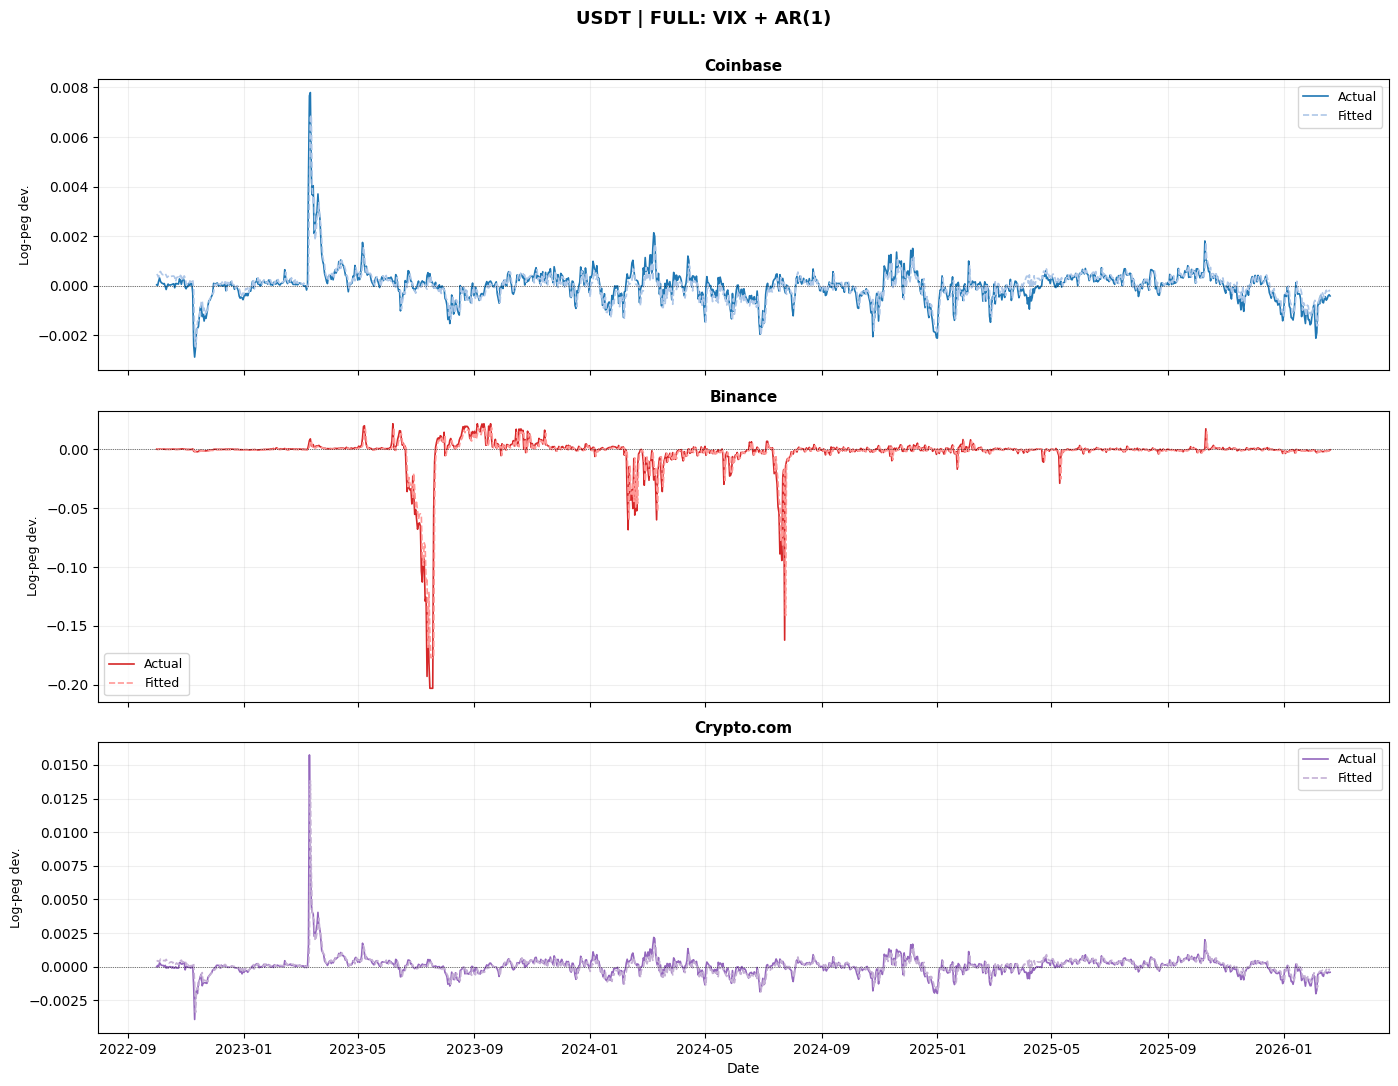

✅ Saved: figures/main/usdt_calm_vix_ar1.png


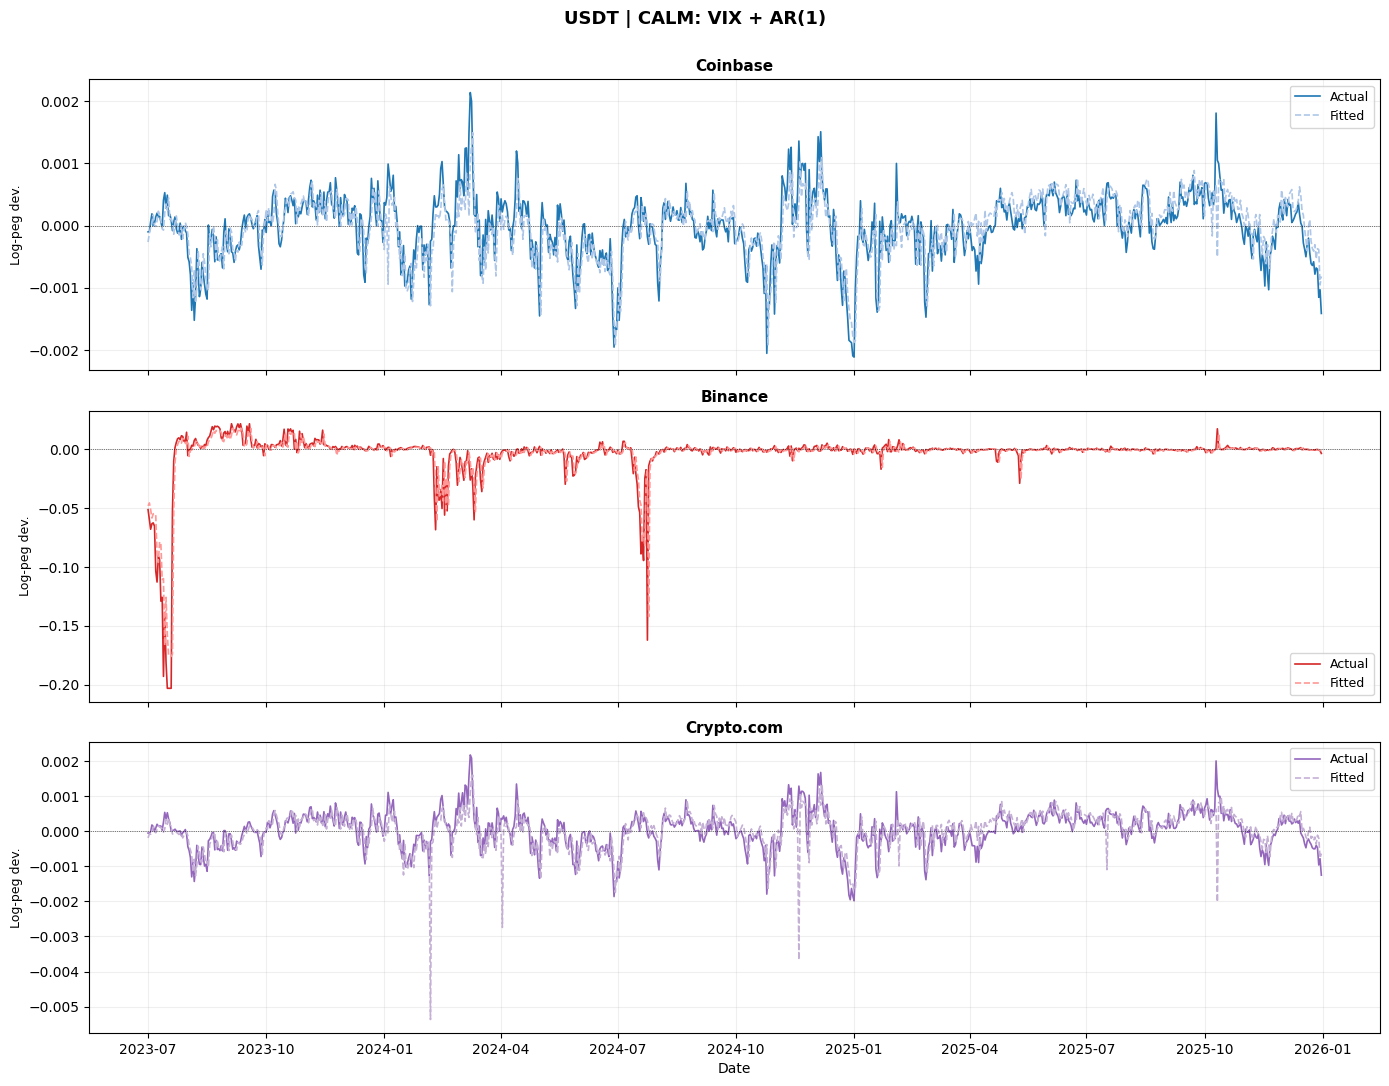

✅ Saved: figures/appendix/usdt_highvix_fullsample_context.png


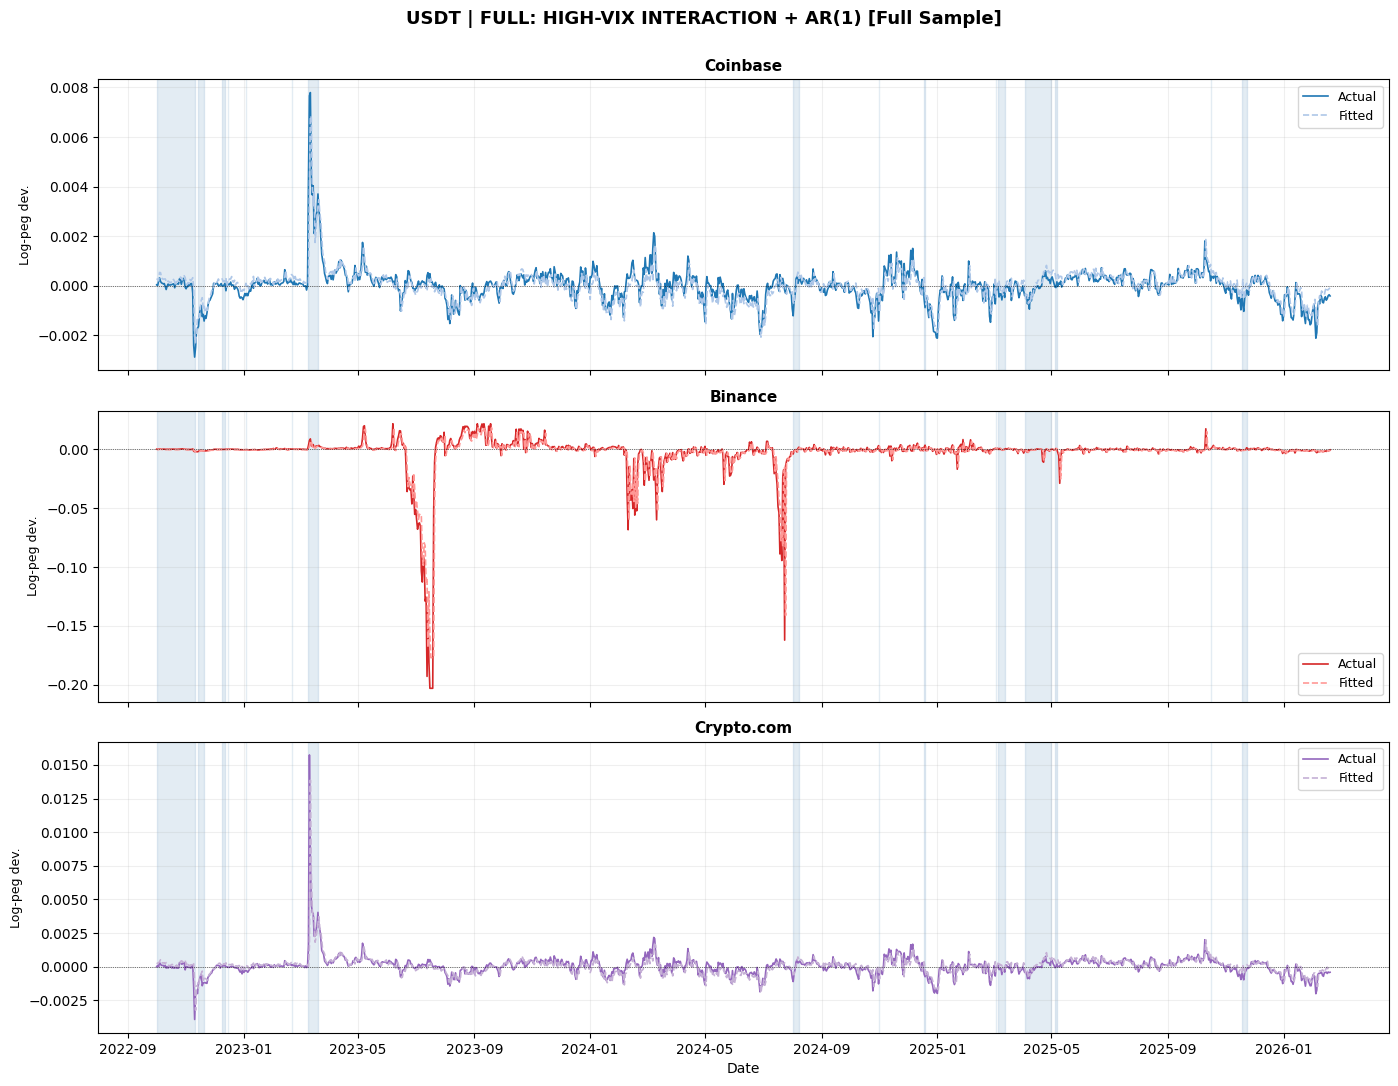

High-VIX blocks found: 12
  2022-09-24 → 2022-11-27
  2022-12-02 → 2022-12-22
  2022-12-27 → 2023-01-10
  2023-02-14 → 2023-02-28
  2023-03-03 → 2023-03-27
  2024-07-26 → 2024-08-15
  2024-10-24 → 2024-11-07
  2024-12-11 → 2024-12-26
  2025-02-25 → 2025-03-20
  2025-03-27 → 2025-05-14
  2025-10-09 → 2025-10-23
  2025-11-11 → 2025-11-30


C:\Users\borto\AppData\Local\Temp\ipykernel_31900\1495709107.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: figures/appendix/usdt_highvix_stress_windows.png


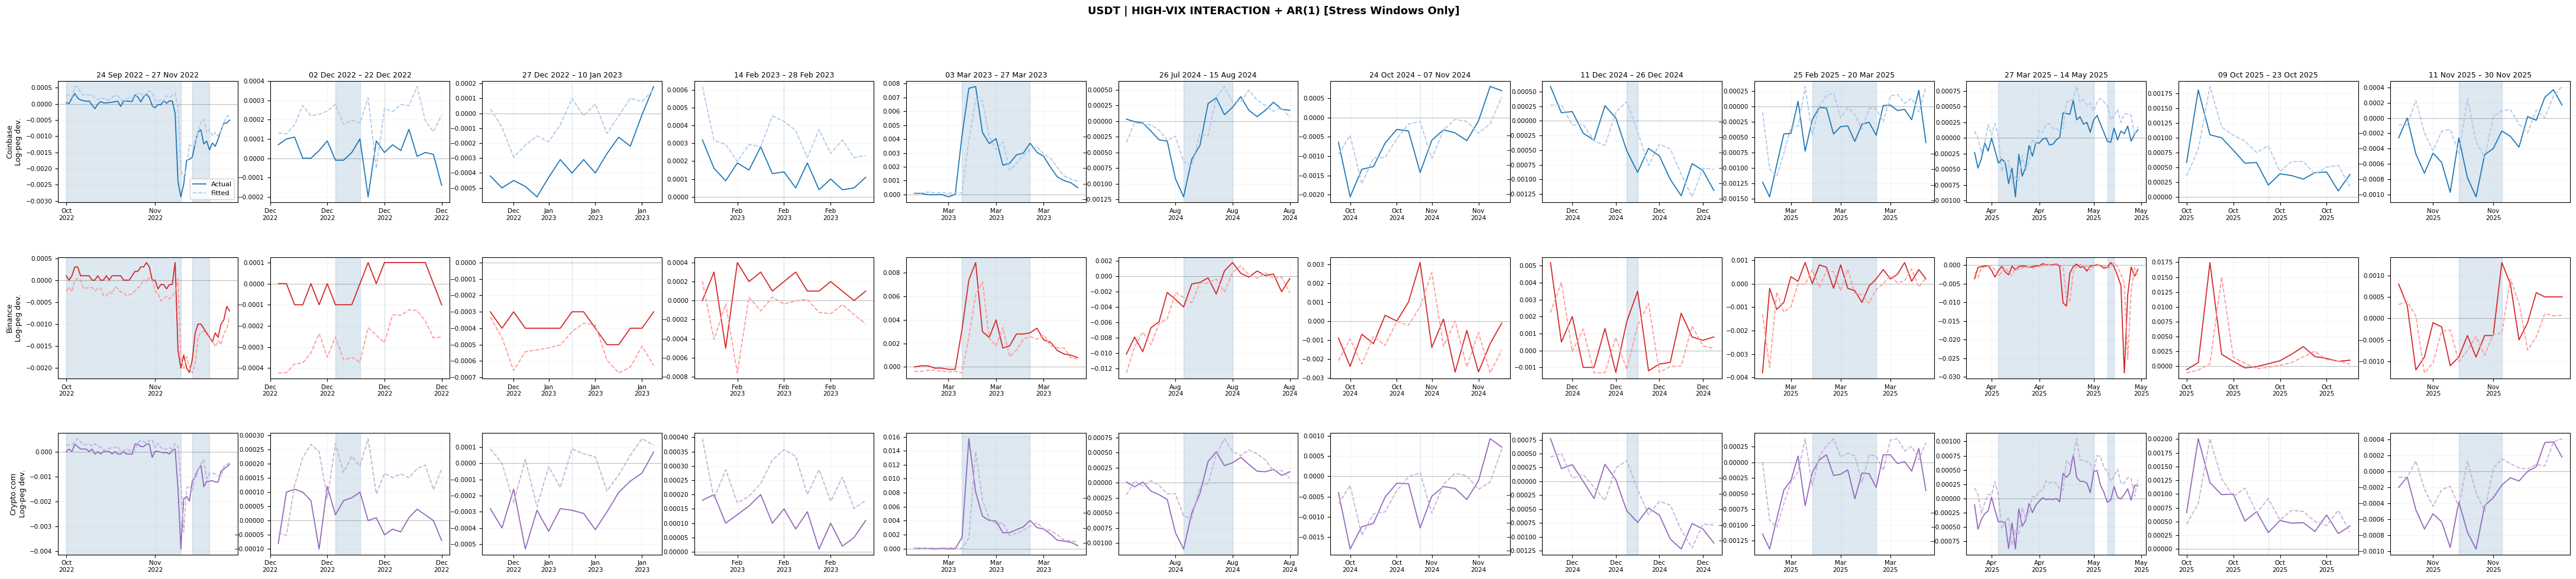

✅ Saved: figures/appendix/usdt_svb_fullsample_context.png


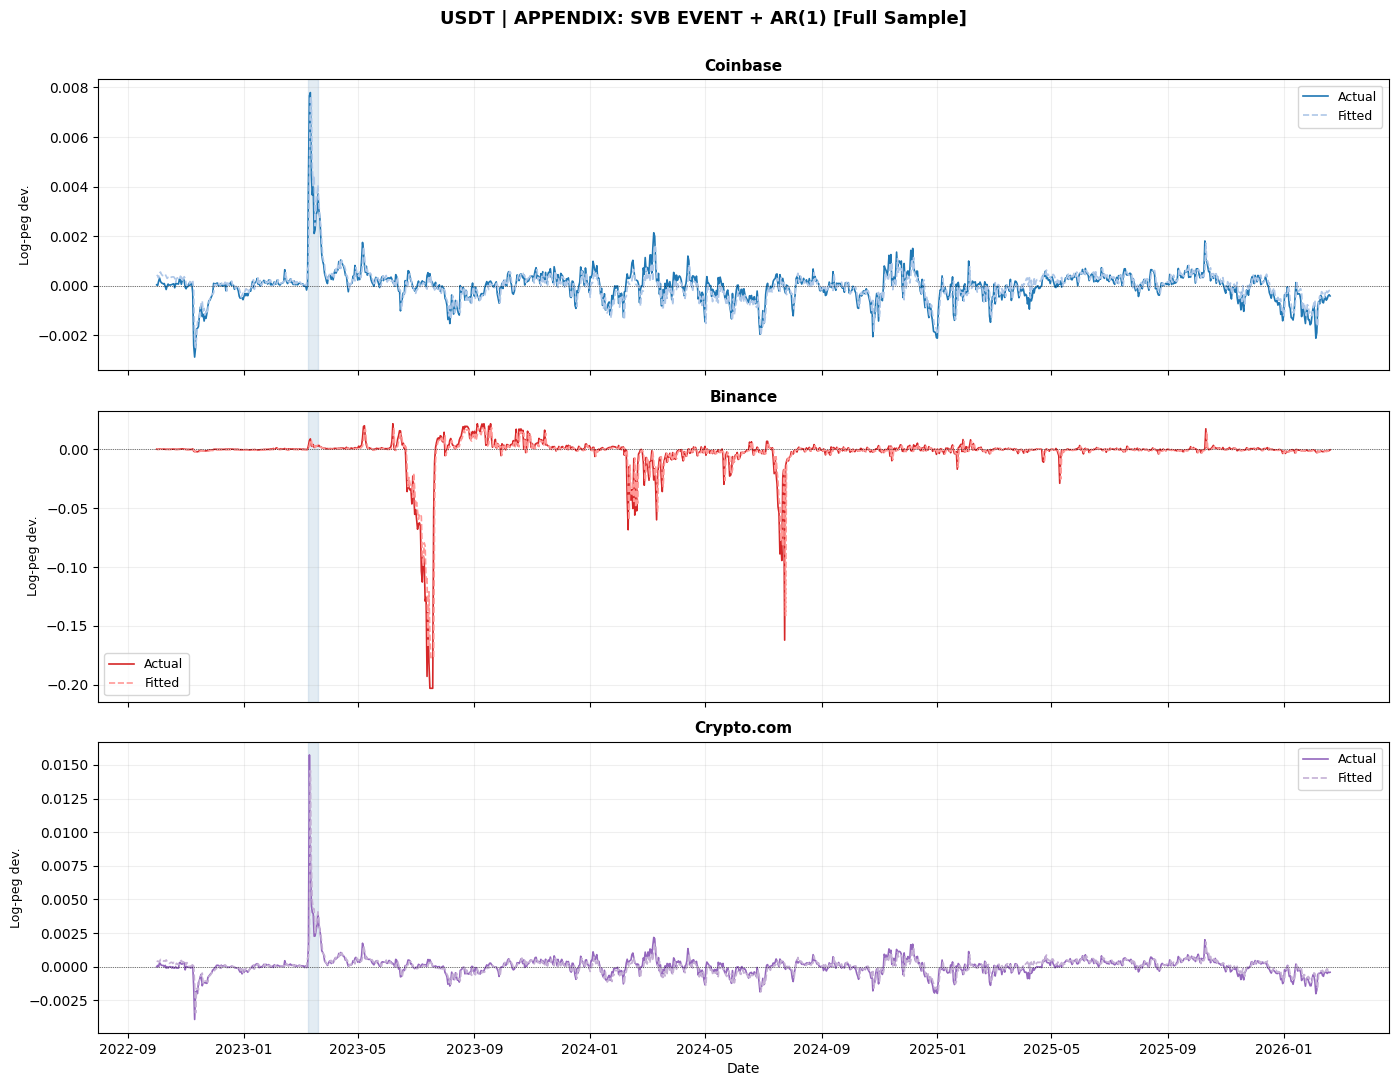

C:\Users\borto\AppData\Local\Temp\ipykernel_31900\1495709107.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ Saved: figures/appendix/usdt_svb_march2023_zoom.png


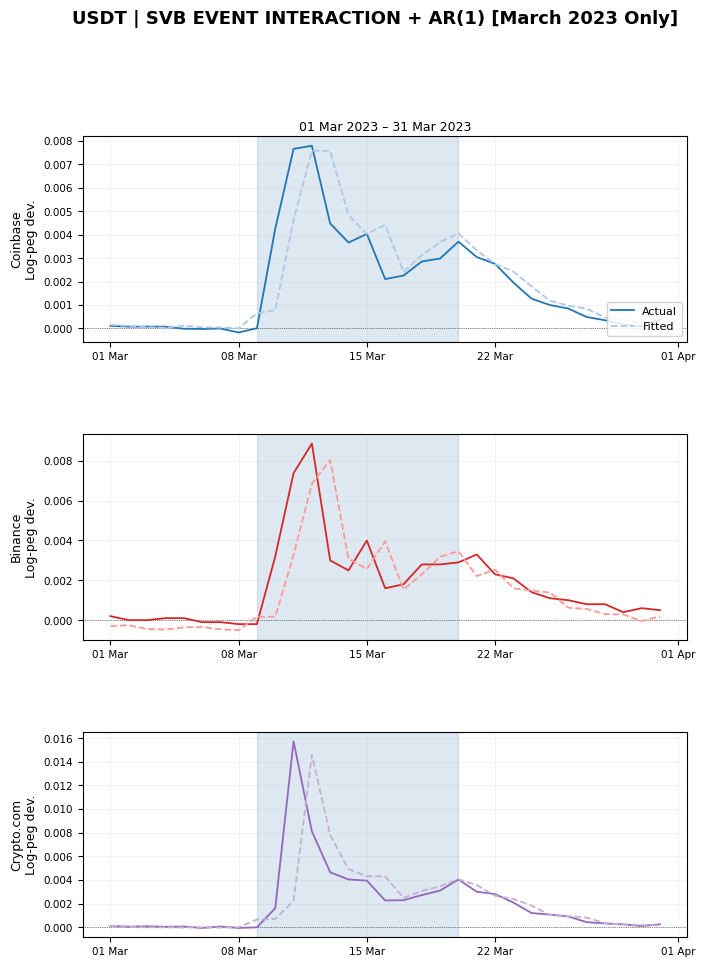

In [ ]:
# (A) STRESS BLOCK EXTRACTOR
def _get_stress_blocks(d, gap_threshold_days=14, buffer_days=7):
    """
    Find contiguous stress==1 date ranges, merge nearby blocks
    (within gap_threshold_days), then expand by buffer_days.
    Returns list of (start, end) Timestamps.
    """
    if d is None or d.empty or "stress" not in d.columns:
        return []

    tmp = (d[["date", "stress"]].dropna()
             .assign(date=lambda x: pd.to_datetime(x["date"]))
             .groupby("date", as_index=False)["stress"].max())
    stress_dates = tmp.loc[tmp["stress"] == 1, "date"].sort_values().reset_index(drop=True)

    if len(stress_dates) == 0:
        return []

    gap = pd.Timedelta(days=gap_threshold_days)
    buf = pd.Timedelta(days=buffer_days)

    blocks = []
    b_start = stress_dates.iloc[0]
    b_end   = stress_dates.iloc[0]

    for dt in stress_dates.iloc[1:]:
        if dt - b_end <= gap:
            b_end = dt
        else:
            blocks.append((b_start - buf, b_end + buf))
            b_start = dt
            b_end   = dt
    blocks.append((b_start - buf, b_end + buf))

    return blocks


def _fixed_window_blocks(x_start, x_end):
    """Single fixed window (e.g. SVB)."""
    return [(pd.Timestamp(x_start), pd.Timestamp(x_end))]


# (B) FIT HELPERS (unchanged from regression code)
def _fit_main_and_attach(data, separate_lk=False):
    required = ["y", "exchange", "date", "L", "K", "vix", "hl_lag1", "vol_lag1", "y_lag1"]
    d = data.dropna(subset=required).copy()
    if len(d) == 0:
        return None, None
    d, rhs = build_regressors_in_sample(d, include_vix=True, separate_lk=separate_lk)
    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = pd.concat([d[["y_lag1"]].astype(float), d[rhs].astype(float), ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    res = sm.OLS(d["y"].astype(float), X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    d["y_hat"] = res.fittedvalues
    return d, res


def _fit_stress_and_attach(data, stress_col, separate_lk=False):
    required = ["y", "exchange", "date", "L", "K", "vix", stress_col,
                "hl_lag1", "vol_lag1", "y_lag1"]
    d = data.dropna(subset=required).copy()
    if len(d) == 0:
        return None, None
    d["zL"]    = zscore_in_sample(d, "L")
    d["zK"]    = zscore_in_sample(d, "K")
    d["vix_c"] = d["vix"] - d["vix"].mean()
    d["stress"] = d[stress_col].astype(int)

    if separate_lk:
        d["zL_x_stress"]   = d["zL"]  * d["stress"]
        d["zK_x_stress"]   = d["zK"]  * d["stress"]
        d["vixc_x_stress"] = d["vix_c"] * d["stress"]
        rhs = ["zL", "zK", "vix_c", "stress",
                "zL_x_stress", "zK_x_stress", "vixc_x_stress",
                "hl_lag1", "vol_lag1"]
    else:
        d["safety"]          = d["zL"] + d["zK"]
        d["safety_x_stress"] = d["safety"] * d["stress"]
        d["vixc_x_stress"]   = d["vix_c"]  * d["stress"]
        rhs = ["safety", "vix_c", "stress",
                "safety_x_stress", "vixc_x_stress",
                "hl_lag1", "vol_lag1"]

    ex_dum = pd.get_dummies(d["exchange"], drop_first=True).astype(float)
    X = pd.concat([d[["y_lag1"]].astype(float), d[rhs].astype(float), ex_dum], axis=1)
    X = sm.add_constant(X, has_constant="add")
    res = sm.OLS(d["y"].astype(float), X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    d["y_hat"] = res.fittedvalues
    return d, res


# (C) NORMALIZE EXCHANGE NAMES
def _normalize_exchange_name(ex):
    exs = str(ex).lower().strip()
    if "coinbase"  in exs: return "coinbase"
    if "binance"   in exs: return "binance"
    if ("crypto.com" in exs) or ("cryptocom" in exs) or ("cdc" in exs): return "crypto.com"
    if "kraken"    in exs: return "kraken"
    return exs

COLOR_MAP = {
    "coinbase":   {"actual": "#1f77b4", "fitted": "#aec7e8", "disp": "Coinbase"},
    "kraken":     {"actual": "#ff7f0e", "fitted": "#ffbb78", "disp": "Kraken"},
    "binance":    {"actual": "#d62728", "fitted": "#ff9896", "disp": "Binance"},
    "crypto.com": {"actual": "#9467bd", "fitted": "#c5b0d5", "disp": "Crypto.com"},
}

PREFERRED_ORDER = ["coinbase", "kraken", "binance", "crypto.com"]


# (D) CORE ZOOM PLOT — one column per stress block
def plot_stress_windows(
    d,
    label,
    blocks,                  # list of (start_ts, end_ts) — from _get_stress_blocks
    shade_stress=True,       # shade stress==1 within each window
    sharey_cols=False,       # share y-axis across stress blocks (same row)
    sharey_rows=False,       # share y-axis across exchanges (same block)
    save_path=None,
    dpi=300,
    row_height=3.2,
    col_width=4.5,
    date_fmt="%b\n%Y",
    max_date_ticks=5,
):
    """
    TRUE ZOOM PLOT.
    Rows    = exchanges
    Columns = stress blocks (non-stress dates completely absent)

    Each cell shows actual vs fitted for one exchange in one stress window.
    """
    if d is None or d.empty:
        print(f"❌ No data: {label}")
        return

    d = d.copy()
    d["date"]          = pd.to_datetime(d["date"])
    d["exchange_plot"] = d["exchange"].map(_normalize_exchange_name)

    present    = [e for e in PREFERRED_ORDER if e in set(d["exchange_plot"].dropna())]
    others     = [e for e in sorted(set(d["exchange_plot"].dropna())) if e not in PREFERRED_ORDER]
    exchanges  = present + others
    n_exc      = len(exchanges)
    n_blocks   = len(blocks)

    if n_exc == 0 or n_blocks == 0:
        print(f"❌ No exchanges or stress blocks for: {label}")
        return

    fig_w = col_width * n_blocks + 0.8
    fig_h = row_height * n_exc   + 0.8

    fig = plt.figure(figsize=(fig_w, fig_h))
    fig.suptitle(label, fontsize=13, fontweight="bold", y=1.002)

    gs = GridSpec(
        n_exc, n_blocks,
        figure=fig,
        hspace=0.45,
        wspace=0.18,
    )

    axes_grid = {}

    for ci, (b_start, b_end) in enumerate(blocks):
        block_data = d[(d["date"] >= b_start) & (d["date"] <= b_end)].copy()

        for ri, ex in enumerate(exchanges):
            share_y_ax = None
            if sharey_cols and ri > 0:
                share_y_ax = axes_grid.get((0, ci))
            if sharey_rows and ci > 0:
                share_y_ax = axes_grid.get((ri, 0))

            ax = fig.add_subplot(gs[ri, ci], sharey=share_y_ax)
            axes_grid[(ri, ci)] = ax

            sub = block_data[block_data["exchange_plot"] == ex].sort_values("date")
            cm  = COLOR_MAP.get(ex, {"actual": "black", "fitted": "grey", "disp": ex})

            if sub.empty:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", va="center", color="grey", fontsize=9)
            else:
                if shade_stress and "stress" in sub.columns:
                    stress_rows = sub[sub["stress"] == 1]
                    if not stress_rows.empty:
                        s_dates = stress_rows["date"].sort_values()
                        gaps  = s_dates.diff() > pd.Timedelta(days=2)
                        run_s = s_dates[gaps | (s_dates == s_dates.iloc[0])]
                        run_e = s_dates[gaps.shift(-1, fill_value=True)]
                        for rs, re in zip(run_s, run_e):
                            ax.axvspan(rs, re, alpha=0.18,
                                       color="steelblue", zorder=0)

                ax.plot(sub["date"], sub["y"],
                        color=cm["actual"], linewidth=1.3,
                        label="Actual", zorder=2)
                ax.plot(sub["date"], sub["y_hat"],
                        color=cm["fitted"], linewidth=1.3,
                        linestyle="--", label="Fitted", zorder=2)
                ax.axhline(0, color="black", linewidth=0.5,
                           linestyle=":", zorder=1)
                ax.grid(True, alpha=0.2, linewidth=0.5)

            if ri == 0:
                col_title = f"{b_start.strftime('%d %b %Y')} – {b_end.strftime('%d %b %Y')}"
                ax.set_title(col_title, fontsize=9, pad=4)

            if ci == 0:
                ax.set_ylabel(cm["disp"] + "\nLog-peg dev.", fontsize=9)
            else:
                ax.set_ylabel("")

            if ri == 0 and ci == 0 and not sub.empty:
                ax.legend(fontsize=8, frameon=True, framealpha=0.85,
                          loc="lower right")

            ax.xaxis.set_major_locator(
                mdates.AutoDateLocator(minticks=2, maxticks=max_date_ticks))
            ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
            ax.tick_params(axis="x", labelsize=7.5)
            ax.tick_params(axis="y", labelsize=7.5)

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")

    plt.show()


# (E) FULL-SAMPLE PLOT (unchanged, used for context/appendix)
def plot_full_sample(
    d, label,
    shade_stress=False,
    sharey=False,
    save_path=None,
    dpi=300,
    fig_width=14,
    row_height=3.6,
):
    if d is None or d.empty:
        print(f"❌ No data: {label}")
        return

    d = d.copy()
    d["date"]          = pd.to_datetime(d["date"])
    d["exchange_plot"] = d["exchange"].map(_normalize_exchange_name)

    present   = [e for e in PREFERRED_ORDER if e in set(d["exchange_plot"].dropna())]
    others    = [e for e in sorted(set(d["exchange_plot"].dropna())) if e not in PREFERRED_ORDER]
    plot_order = present + others

    fig, axes = plt.subplots(
        nrows=len(plot_order), ncols=1,
        figsize=(fig_width, row_height * len(plot_order)),
        sharex=True, sharey=sharey,
    )
    if len(plot_order) == 1:
        axes = [axes]

    def _shade(ax, df_):
        if "stress" not in df_.columns or df_.empty:
            return
        s = (df_[["date","stress"]].dropna()
               .groupby("date", as_index=False)["stress"].max()
               .sort_values("date"))
        dates = s["date"].to_numpy()
        vals  = s["stress"].astype(int).to_numpy()
        in_b  = False
        for i in range(len(vals)):
            if vals[i] == 1 and not in_b:
                in_b = True; sd = dates[i]
            if in_b and (i == len(vals)-1 or vals[i+1] == 0):
                ax.axvspan(sd, dates[i], alpha=0.15, color="steelblue")
                in_b = False

    for ax, ex in zip(axes, plot_order):
        sub = d[d["exchange_plot"] == ex].sort_values("date")
        cm  = COLOR_MAP.get(ex, {"actual": "black", "fitted": "grey", "disp": ex})
        if shade_stress:
            _shade(ax, sub)
        if not sub.empty:
            ax.plot(sub["date"], sub["y"],     color=cm["actual"], linewidth=1.2, label="Actual")
            ax.plot(sub["date"], sub["y_hat"], color=cm["fitted"], linewidth=1.2, linestyle="--", label="Fitted")
            ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
        ax.set_ylabel("Log-peg dev.", fontsize=9)
        ax.set_title(cm["disp"], fontsize=11, fontweight="bold")
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=9, frameon=True)

    axes[-1].set_xlabel("Date")
    fig.suptitle(label, fontsize=13, fontweight="bold", y=1.001)
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"✅ Saved: {save_path}")

    plt.show()


# (F) RUN ALL PLOTS  [UPDATED: with save paths]
os.makedirs("figures/main", exist_ok=True)
os.makedirs("figures/appendix", exist_ok=True)

coin_tag = str(COIN_LABEL).lower().replace(" ", "_")

# ── 1) FULL SAMPLE: VIX + AR(1) ──────────────────────────
fit_full_main_df, fit_full_main_res = _fit_main_and_attach(
    df_full, separate_lk=SEPARATE_LK)

plot_full_sample(
    fit_full_main_df,
    f"{COIN_LABEL} | FULL: VIX + AR(1)",
    shade_stress=False,
    save_path=f"figures/main/{coin_tag}_full_vix_ar1.png",   # <- save
    dpi=300,
)

# ── 2) CALM: VIX + AR(1) ─────────────────────────────────
fit_calm_main_df, fit_calm_main_res = _fit_main_and_attach(
    df_calm, separate_lk=SEPARATE_LK)

plot_full_sample(
    fit_calm_main_df,
    f"{COIN_LABEL} | CALM: VIX + AR(1)",
    shade_stress=False,
    save_path=f"figures/main/{coin_tag}_calm_vix_ar1.png",   # <- save (likely main paper figure)
    dpi=300,
)

# ── 3) HIGH-VIX INTERACTION ───────────────────────────────
if USE_HIGH_VIX_STRESS:
    fit_stress_vix_df, fit_stress_vix_res = _fit_stress_and_attach(
        df_full, "stress_vix", separate_lk=SEPARATE_LK)

    plot_full_sample(
        fit_stress_vix_df,
        f"{COIN_LABEL} | FULL: HIGH-VIX INTERACTION + AR(1) [Full Sample]",
        shade_stress=True,
        save_path=f"figures/appendix/{coin_tag}_highvix_fullsample_context.png",  # <- save
        dpi=300,
    )

    # ★ TRUE ZOOM — only high-VIX blocks, non-stress dates removed ★
    vix_blocks = _get_stress_blocks(
        fit_stress_vix_df,
        gap_threshold_days=14,
        buffer_days=7,
    )
    print(f"High-VIX blocks found: {len(vix_blocks)}")
    for b in vix_blocks:
        print(f"  {b[0].date()} → {b[1].date()}")

    plot_stress_windows(
        fit_stress_vix_df,
        f"{COIN_LABEL} | HIGH-VIX INTERACTION + AR(1) [Stress Windows Only]",
        blocks=vix_blocks,
        shade_stress=True,
        sharey_cols=False,
        sharey_rows=False,
        col_width=4.5,
        row_height=3.2,
        save_path=f"figures/appendix/{coin_tag}_highvix_stress_windows.png",
        dpi=300,
    )
else:
    fit_stress_vix_df = None
    print("High-VIX stress disabled.")

# ── 4) SVB EVENT INTERACTION ──────────────────────────────
if RUN_SVB_EVENT_APPENDIX:
    fit_stress_event_df, fit_stress_event_res = _fit_stress_and_attach(
        df_full, "stress_event", separate_lk=SEPARATE_LK)


    plot_full_sample(
        fit_stress_event_df,
        f"{COIN_LABEL} | APPENDIX: SVB EVENT + AR(1) [Full Sample]",
        shade_stress=True,
        save_path=f"figures/appendix/{coin_tag}_svb_fullsample_context.png",
        dpi=300,
    )

    # ★ TRUE ZOOM — only March 2023 window ★
    svb_blocks = _fixed_window_blocks("2023-03-01", "2023-03-31")

    plot_stress_windows(
        fit_stress_event_df,
        f"{COIN_LABEL} | SVB EVENT INTERACTION + AR(1) [March 2023 Only]",
        blocks=svb_blocks,
        shade_stress=True,
        col_width=7,
        row_height=3.2,
        date_fmt="%d %b",
        max_date_ticks=8,
        save_path=f"figures/appendix/{coin_tag}_svb_march2023_zoom.png",
        dpi=300,
    )
else:
    fit_stress_event_df = None
    print("SVB appendix disabled.")

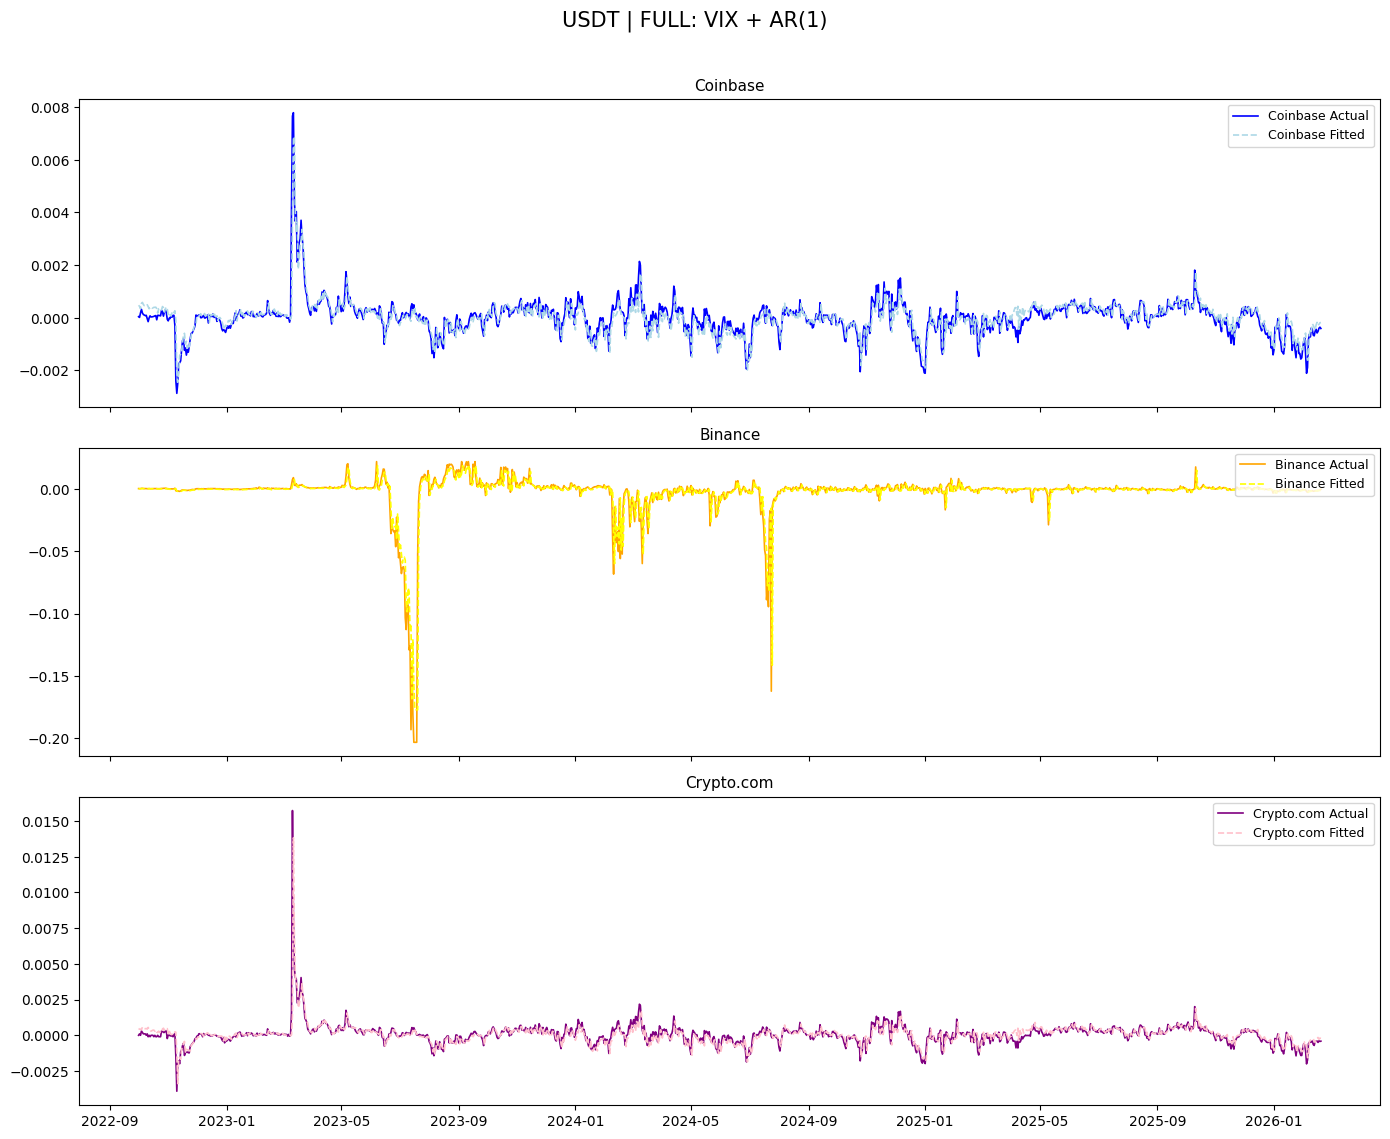

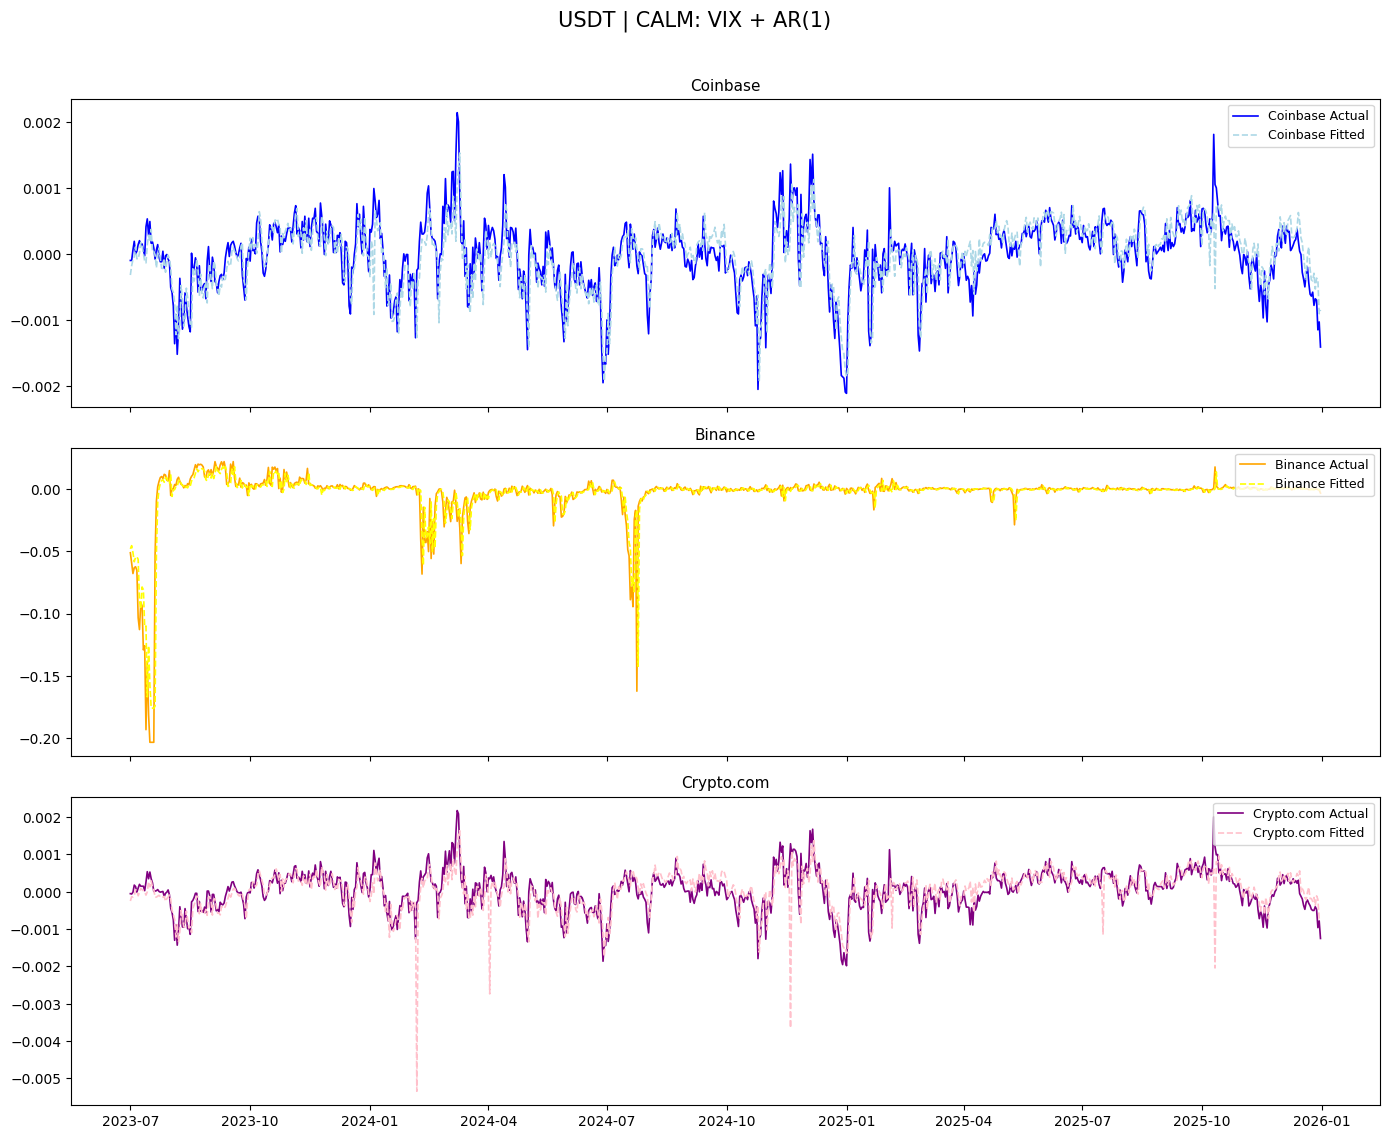

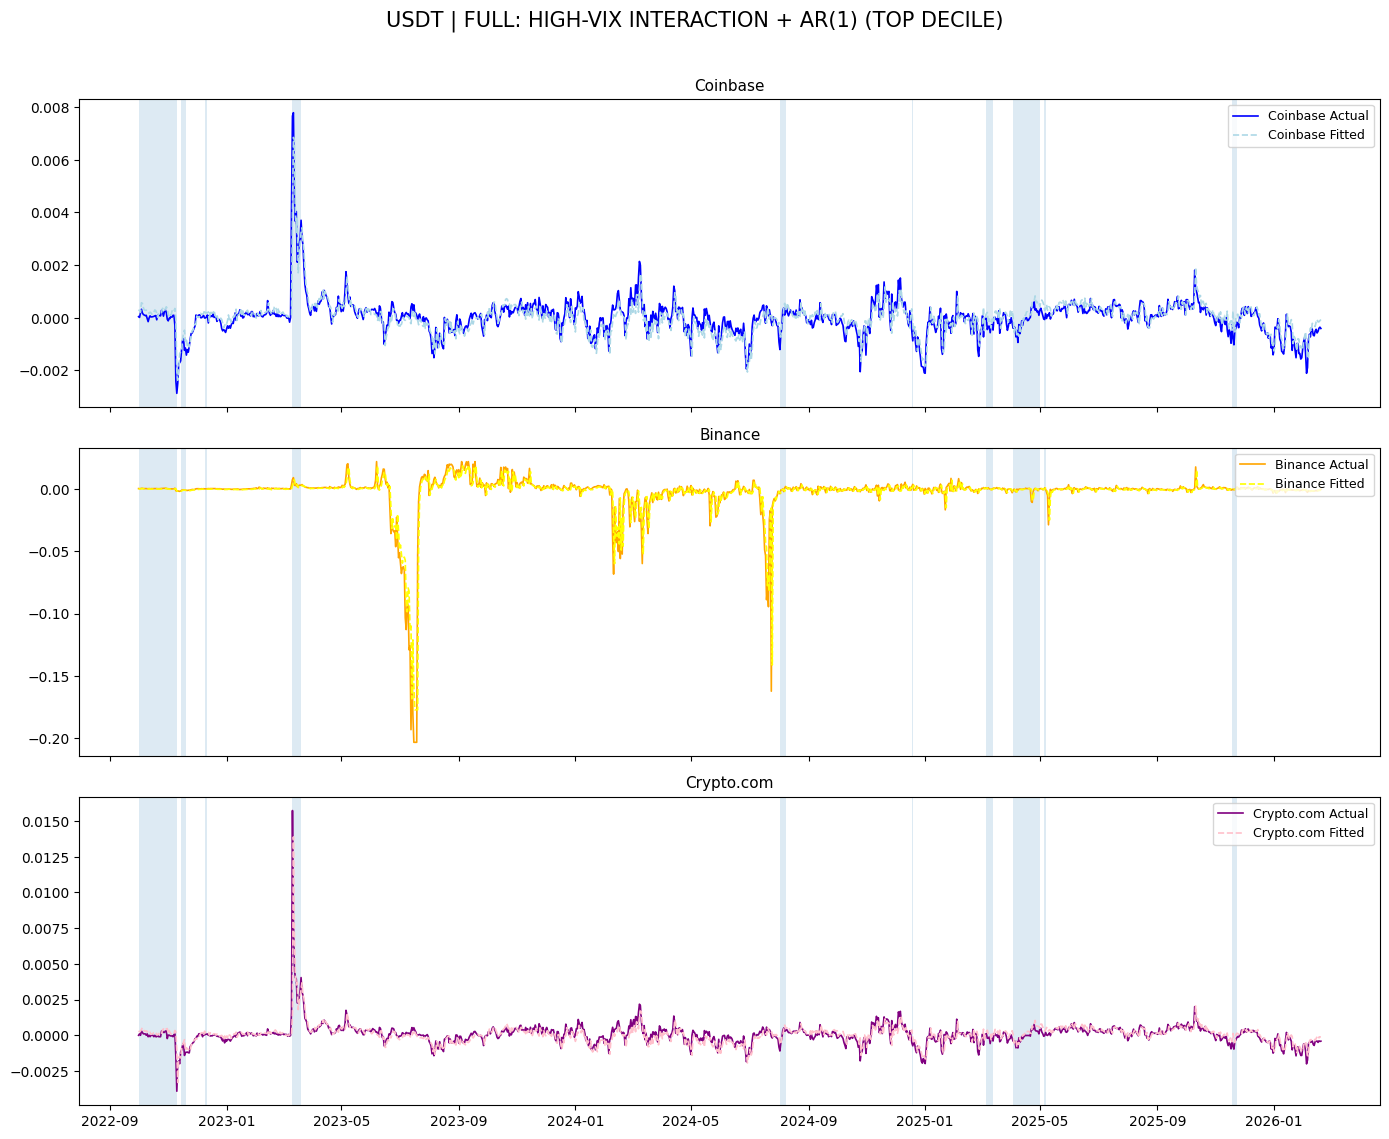

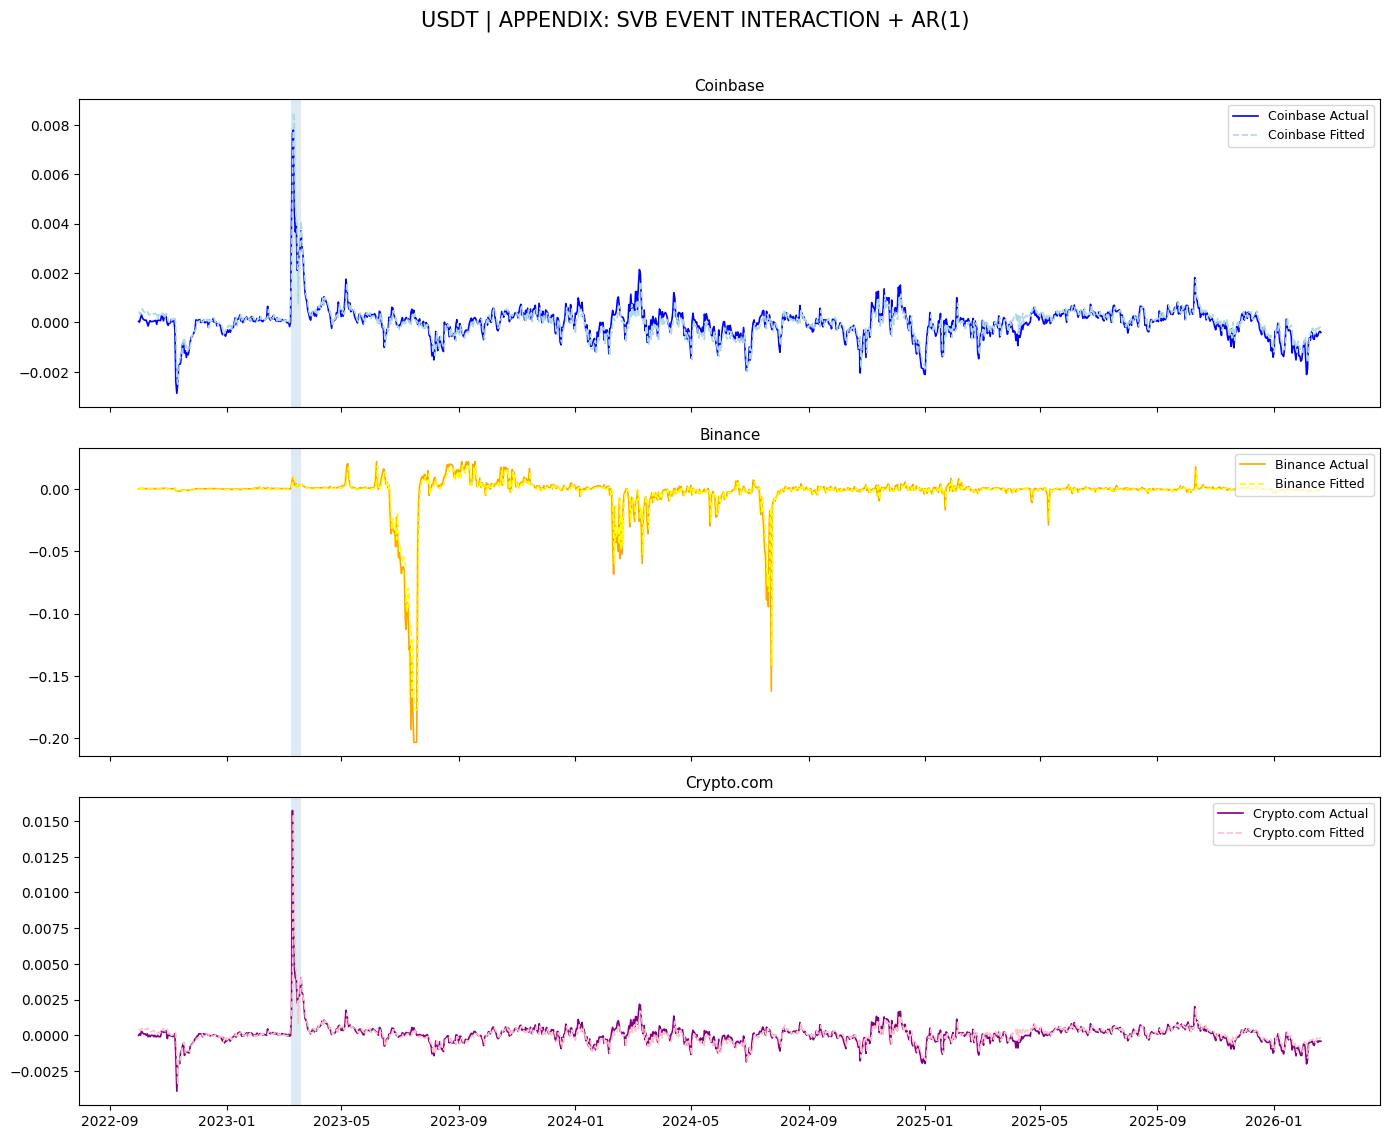

In [ ]:
import matplotlib.pyplot as plt

def _normalize_exchange_name(ex):
    exs = str(ex).lower().strip()
    if "coinbase" in exs:
        return "coinbase"
    if "binance" in exs:
        return "binance"
    if ("crypto.com" in exs) or ("cryptocom" in exs) or ("cdc" in exs):
        return "crypto.com"
    return exs

def _shade_stress_blocks_global(ax, d):
    """Shade stress windows using date-level max stress across exchanges."""
    if ("stress" not in d.columns) or d.empty:
        return

    s = (
        d[["date", "stress"]]
        .dropna()
        .groupby("date", as_index=False)["stress"].max()
        .sort_values("date")
    )
    if s.empty:
        return

    dates = s["date"].to_numpy()
    vals  = s["stress"].astype(int).to_numpy()

    in_block = False
    start_dt = None
    for i in range(len(vals)):
        if vals[i] == 1 and not in_block:
            in_block = True
            start_dt = dates[i]
        is_last = (i == len(vals) - 1)
        if in_block and (is_last or vals[i + 1] == 0):
            end_dt = dates[i]
            ax.axvspan(start_dt, end_dt, alpha=0.15)
            in_block = False
            start_dt = None

def _plot_actual_vs_fitted_stacked_exchanges(d, label, shade_stress=False, sharey=True):
    """
    One figure with 3 stacked subplots (Coinbase, Binance, Crypto.com).
    sharey=True makes comparison easier; set False if Binance dominates scale too much.
    """
    if d is None or d.empty:
        print(f"❌ No data to plot for {label}")
        return

    color_map = {
        "coinbase":   {"actual": "blue",   "fitted": "lightblue", "disp": "Coinbase"},
        "binance":    {"actual": "orange", "fitted": "yellow",    "disp": "Binance"},
        "crypto.com": {"actual": "purple", "fitted": "pink",      "disp": "Crypto.com"},
    }

    d = d.copy()
    d["exchange_plot"] = d["exchange"].map(_normalize_exchange_name)

    order = ["coinbase", "binance", "crypto.com"]
    present = [ex for ex in order if ex in set(d["exchange_plot"].dropna())]

    if len(present) == 0:
        print(f"❌ No recognized exchanges to plot for {label}")
        return

    fig, axes = plt.subplots(
        nrows=len(present),
        ncols=1,
        figsize=(14, 3.8 * len(present)),
        sharex=True,
        sharey=sharey
    )

    if len(present) == 1:
        axes = [axes]

    for ax, ex in zip(axes, present):
        sub = d[d["exchange_plot"] == ex].sort_values("date")
        if sub.empty:
            continue

        c_actual = color_map[ex]["actual"]
        c_fitted = color_map[ex]["fitted"]
        disp     = color_map[ex]["disp"]

        if shade_stress:
            _shade_stress_blocks_global(ax, d)

        ax.plot(sub["date"], sub["y"], label=f"{disp} Actual", linewidth=1.2, color=c_actual)
        ax.plot(sub["date"], sub["y_hat"], label=f"{disp} Fitted", linewidth=1.2, linestyle="--", color=c_fitted)

        ax.set_title(disp, fontsize=11)
        ax.legend(loc="upper right", fontsize=9)

    fig.suptitle(label, fontsize=15, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# 1) FULL: VIX + AR(1)
fit_full_main_df, fit_full_main_res = _fit_usdt_main_and_attach(df_full)
_plot_actual_vs_fitted_stacked_exchanges(
    fit_full_main_df,
    f"{COIN_LABEL} | FULL: VIX + AR(1)",
    shade_stress=False,
    sharey=False   # try False if Binance dominates too much
)

# 2) CALM: VIX + AR(1)
fit_calm_main_df, fit_calm_main_res = _fit_usdt_main_and_attach(df_calm)
_plot_actual_vs_fitted_stacked_exchanges(
    fit_calm_main_df,
    f"{COIN_LABEL} | CALM: VIX + AR(1)",
    shade_stress=False,
    sharey=False
)

# 3) FULL: HIGH-VIX INTERACTION + AR(1)
if USE_HIGH_VIX_STRESS:
    fit_stress_vix_df, fit_stress_vix_res = _fit_usdt_stress_and_attach(df_full, "stress_vix")
    _plot_actual_vs_fitted_stacked_exchanges(
        fit_stress_vix_df,
        f"{COIN_LABEL} | FULL: HIGH-VIX INTERACTION + AR(1) (TOP DECILE)",
        shade_stress=True,
        sharey=False
    )
else:
    fit_stress_vix_df, fit_stress_vix_res = None, None
    print("High-VIX stress disabled (USE_HIGH_VIX_STRESS=False).")

# 4) FULL: SVB EVENT INTERACTION + AR(1) [appendix]
if RUN_SVB_EVENT_APPENDIX:
    fit_stress_event_df, fit_stress_event_res = _fit_usdt_stress_and_attach(df_full, "stress_event")
    _plot_actual_vs_fitted_stacked_exchanges(
        fit_stress_event_df,
        f"{COIN_LABEL} | APPENDIX: SVB EVENT INTERACTION + AR(1)",
        shade_stress=True,
        sharey=False
    )
else:
    fit_stress_event_df, fit_stress_event_res = None, None
    print("SVB appendix disabled (RUN_SVB_EVENT_APPENDIX=False).")